# Comprehensive Exploratory Data Analysis & Integration

## Unit 1: Data Profiling, Pre-processing, and Visualization

This notebook provides a thorough analysis of all 4 primary source datasets before and after merging.

**Datasets:**
- Gym Recommendation (14,589 records)
- Diet Recommendations (1,000 records)
- Personalized Medical Diet (5,000 records)
- Diet Workout Dataset (2,600 records)


In [ ]:
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

sources = {
    'Gym Recommendation': 'data/gym_recommendation.csv',
    'Diet Recommendations': 'data/diet_recommendations.csv',
    'Personalized Medical Diet': 'data/personalized_medical_diet.csv',
    'Diet Workout Dataset': 'data/diet_workout_dataset.csv'
}
MERGED_PATH = 'data/merged_fitness_data.csv'
OUTPUT_DIR = 'data_analysis_charts'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def plot_hist(data, ax, color='steelblue', bins=30, kde=False):
    data_clean = data.dropna()
    ax.hist(data_clean, bins=bins, color=color, edgecolor='black', alpha=0.7)
    if kde and len(data_clean) > 1:
        try:
            kde_x = np.linspace(data_clean.min(), data_clean.max(), 100)
            kde_vals = stats.gaussian_kde(data_clean)(kde_x)
            ax2 = ax.twinx()
            ax2.plot(kde_x, kde_vals, color='darkred', linewidth=2)
            ax2.set_yticks([])
        except:
            pass
    return ax

## 1. Dataset Overview & Basic Information

DATASET SUMMARY TABLE
                  Dataset  Rows  Columns  Missing Values  Duplicate Rows  Numeric Columns  Categorical Columns
       Gym Recommendation 14589       15               0               0                5                   10
     Diet Recommendations  1000       20             861               0               11                    9
Personalized Medical Diet  5000       30            6765               0               19                   11
     Diet Workout Dataset  2600        5               0               0                5                    0


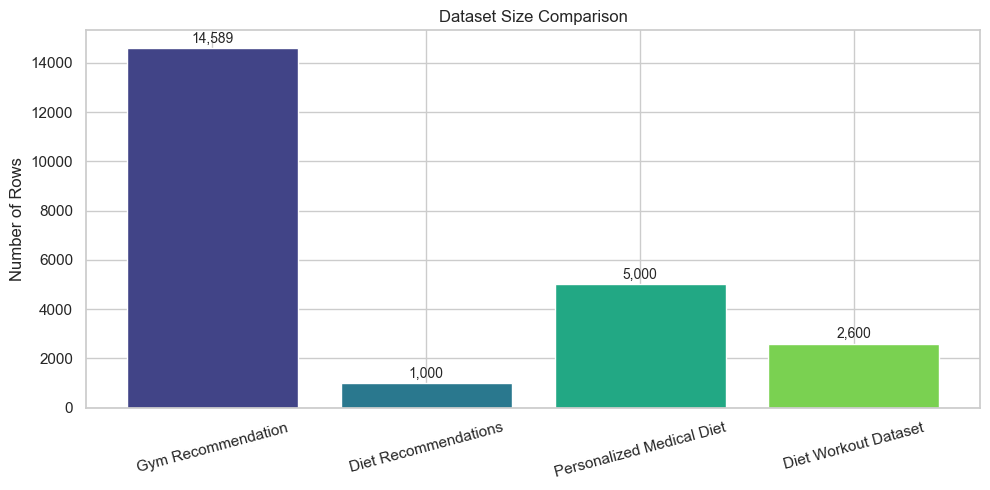

In [ ]:
info_list = []
for name, path in sources.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        info_list.append({
            'Dataset': name,
            'Rows': df.shape[0],
            'Columns': df.shape[1],
            'Missing Values': df.isnull().sum().sum(),
            'Duplicate Rows': df.duplicated().sum(),
            'Numeric Columns': df.select_dtypes(include=[np.number]).shape[1],
            'Categorical Columns': df.select_dtypes(include=['object']).shape[1]
        })

info_df = pd.DataFrame(info_list)
print("=" * 80)
print("DATASET SUMMARY TABLE")
print("=" * 80)
print(info_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(info_df['Dataset'], info_df['Rows'], color=sns.color_palette('viridis', len(info_df)))
ax.set_ylabel('Number of Rows')
ax.set_title('Dataset Size Comparison')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, info_df['Rows']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{val:,}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_dataset_size_comparison.png', dpi=150)
plt.show()

In [ ]:
gym_df.columns

## 2. Data Quality Assessment

### 2.1 Missing Values Analysis

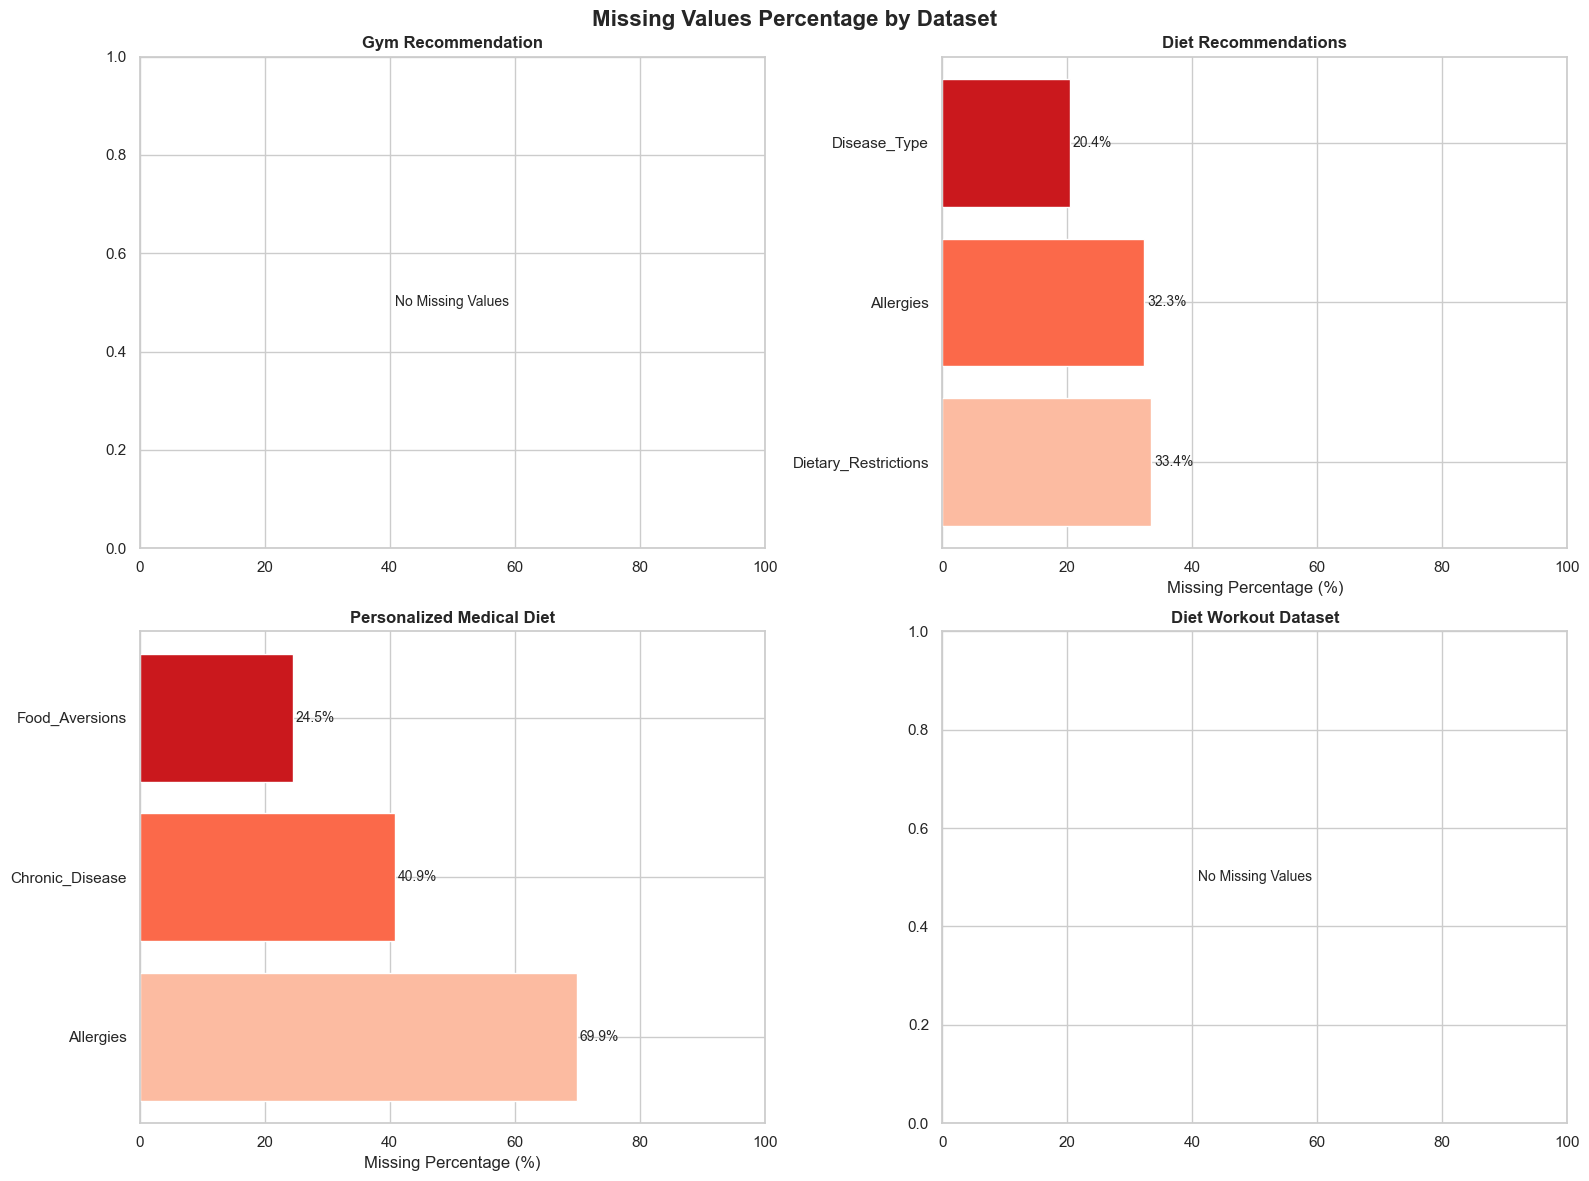

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, path) in enumerate(sources.items()):
    df = pd.read_csv(path)
    missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0]
    
    if len(missing_pct) > 0:
        colors = sns.color_palette('Reds', len(missing_pct))
        axes[idx].barh(missing_pct.index, missing_pct.values, color=colors)
        axes[idx].set_xlabel('Missing Percentage (%)')
        axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
        for i, v in enumerate(missing_pct.values):
            axes[idx].text(v + 0.5, i, f'{v:.1f}%', va='center')
    else:
        axes[idx].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    
    axes[idx].set_xlim(0, max(100, missing_pct.max() + 10) if len(missing_pct) > 0 else 100)

plt.suptitle('Missing Values Percentage by Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_missing_values_analysis.png', dpi=150)
plt.show()

### 2.2 Duplicate Records Analysis

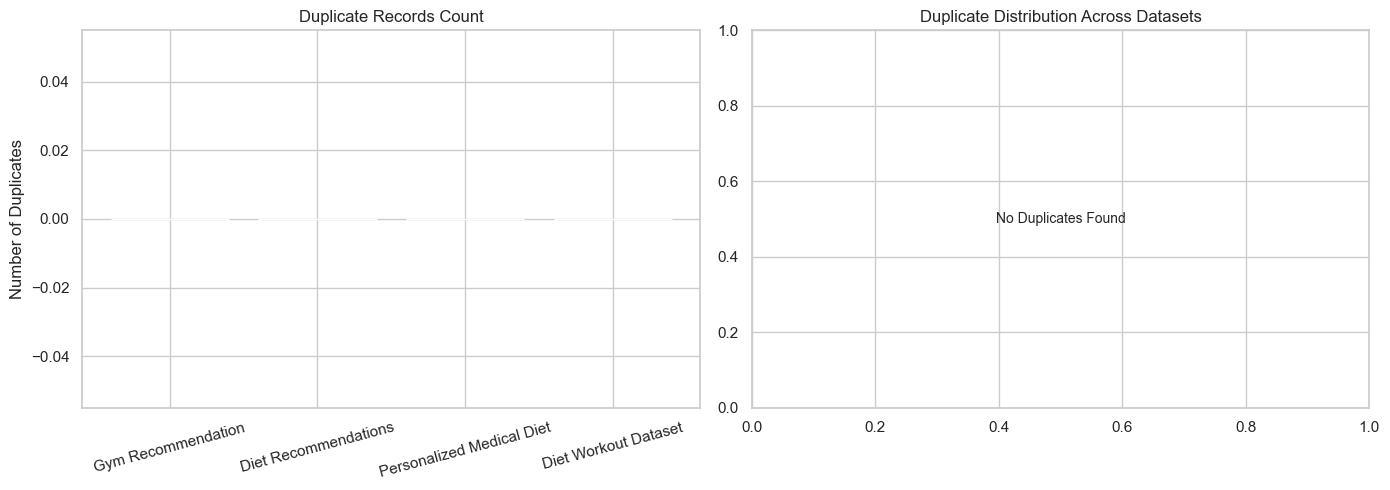

In [52]:
dup_data = []
for name, path in sources.items():
    df = pd.read_csv(path)
    dup_count = df.duplicated().sum()
    dup_pct = dup_count / len(df) * 100
    dup_data.append({'Dataset': name, 'Duplicates': dup_count, 'Percentage': dup_pct})

dup_df = pd.DataFrame(dup_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dup_df['Dataset'], dup_df['Duplicates'], color=sns.color_palette('Oranges', len(dup_df)))
axes[0].set_ylabel('Number of Duplicates')
axes[0].set_title('Duplicate Records Count')
axes[0].tick_params(axis='x', rotation=15)

total_dups = dup_df['Duplicates'].sum()
if total_dups > 0:
    axes[1].pie(dup_df['Duplicates'], labels=dup_df['Dataset'], autopct='%1.1f%%', 
                colors=sns.color_palette('Oranges', len(dup_df)), startangle=90)
else:
    axes[1].text(0.5, 0.5, 'No Duplicates Found', ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_title('Duplicate Distribution Across Datasets')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_duplicate_analysis.png', dpi=150)
plt.show()

## 3. GYM RECOMMENDATION DATASET ANALYSIS

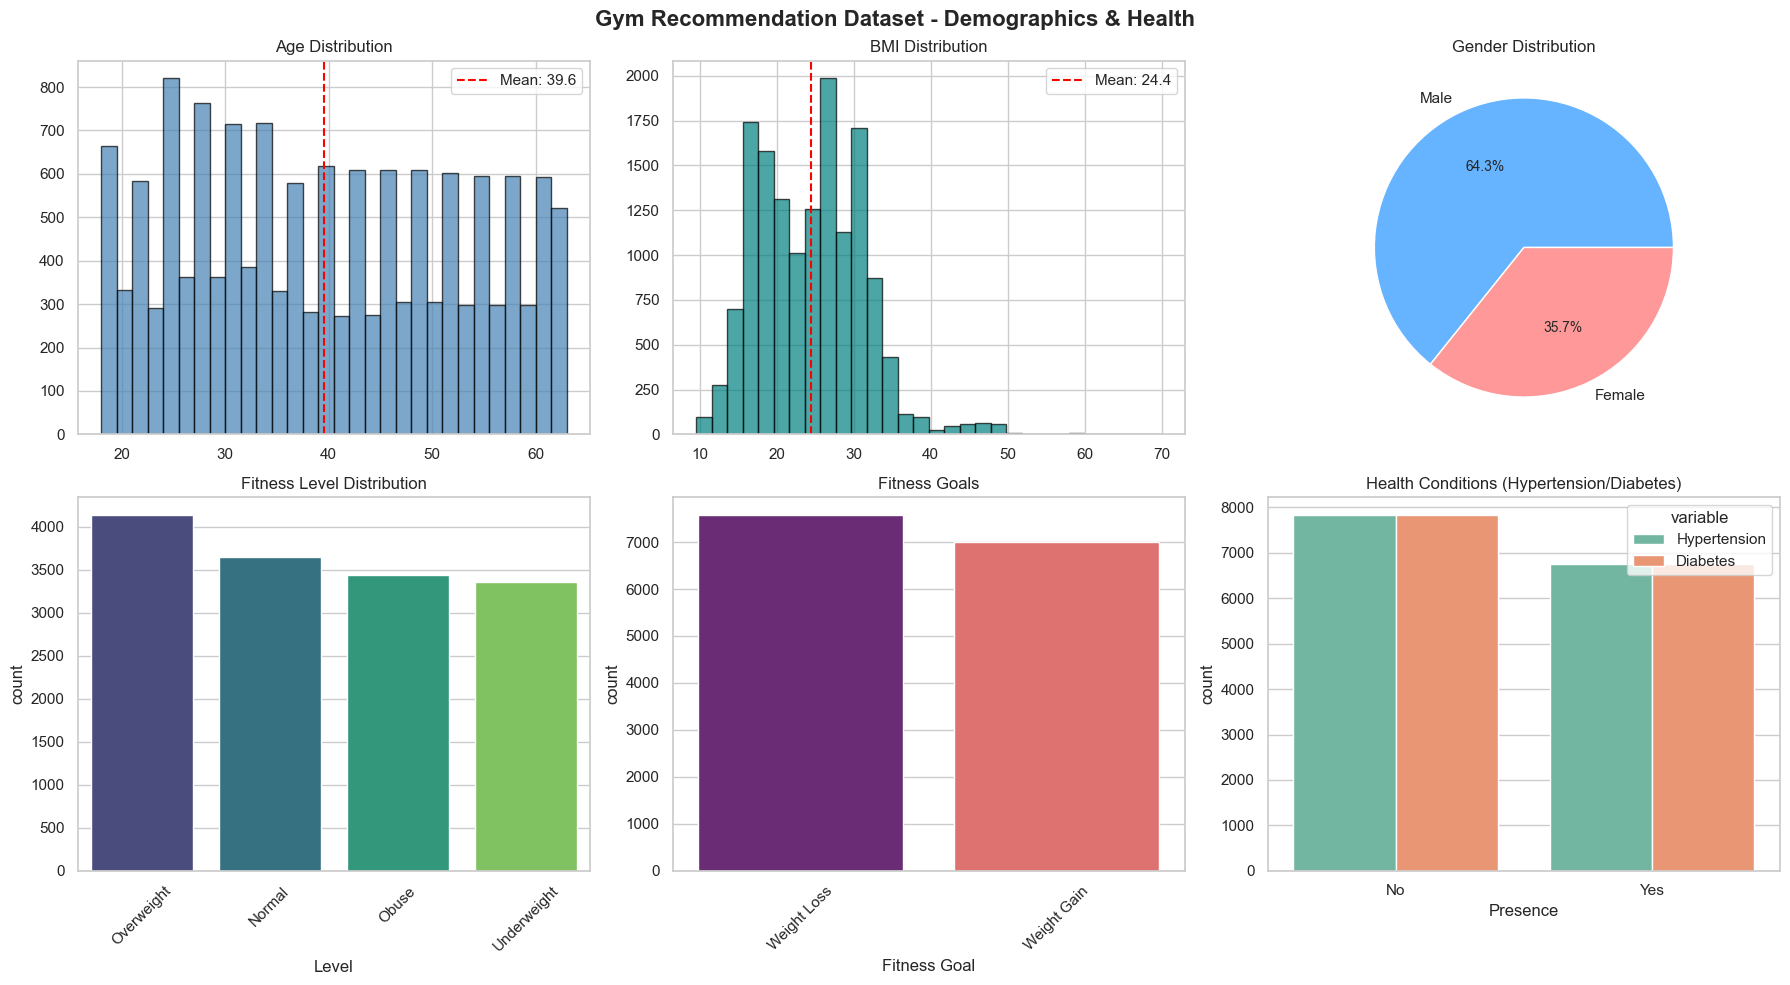

In [53]:
gym_df = pd.read_csv('data/gym_recommendation.csv')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_hist(gym_df['Age'], axes[0, 0], color='steelblue', bins=30)
axes[0, 0].set_title('Age Distribution')
axes[0, 0].axvline(gym_df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {gym_df["Age"].mean():.1f}')
axes[0, 0].legend()

plot_hist(gym_df['BMI'], axes[0, 1], color='teal', bins=30)
axes[0, 1].set_title('BMI Distribution')
axes[0, 1].axvline(gym_df['BMI'].mean(), color='red', linestyle='--', label=f'Mean: {gym_df["BMI"].mean():.1f}')
axes[0, 1].legend()

gym_df['Sex'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0, 2], colors=['#66b3ff', '#ff9999'])
axes[0, 2].set_title('Gender Distribution')
axes[0, 2].set_ylabel('')

sns.countplot(data=gym_df, x='Level', order=gym_df['Level'].value_counts().index, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Fitness Level Distribution')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.countplot(data=gym_df, x='Fitness Goal', order=gym_df['Fitness Goal'].value_counts().index, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Fitness Goals')
axes[1, 1].tick_params(axis='x', rotation=45)

disease_data = gym_df[['Hypertension', 'Diabetes']].melt()
sns.countplot(data=disease_data, x='value', hue='variable', ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('Health Conditions (Hypertension/Diabetes)')
axes[1, 2].set_xlabel('Presence')

plt.suptitle('Gym Recommendation Dataset - Demographics & Health', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_gym_demographics.png', dpi=150)
plt.show()

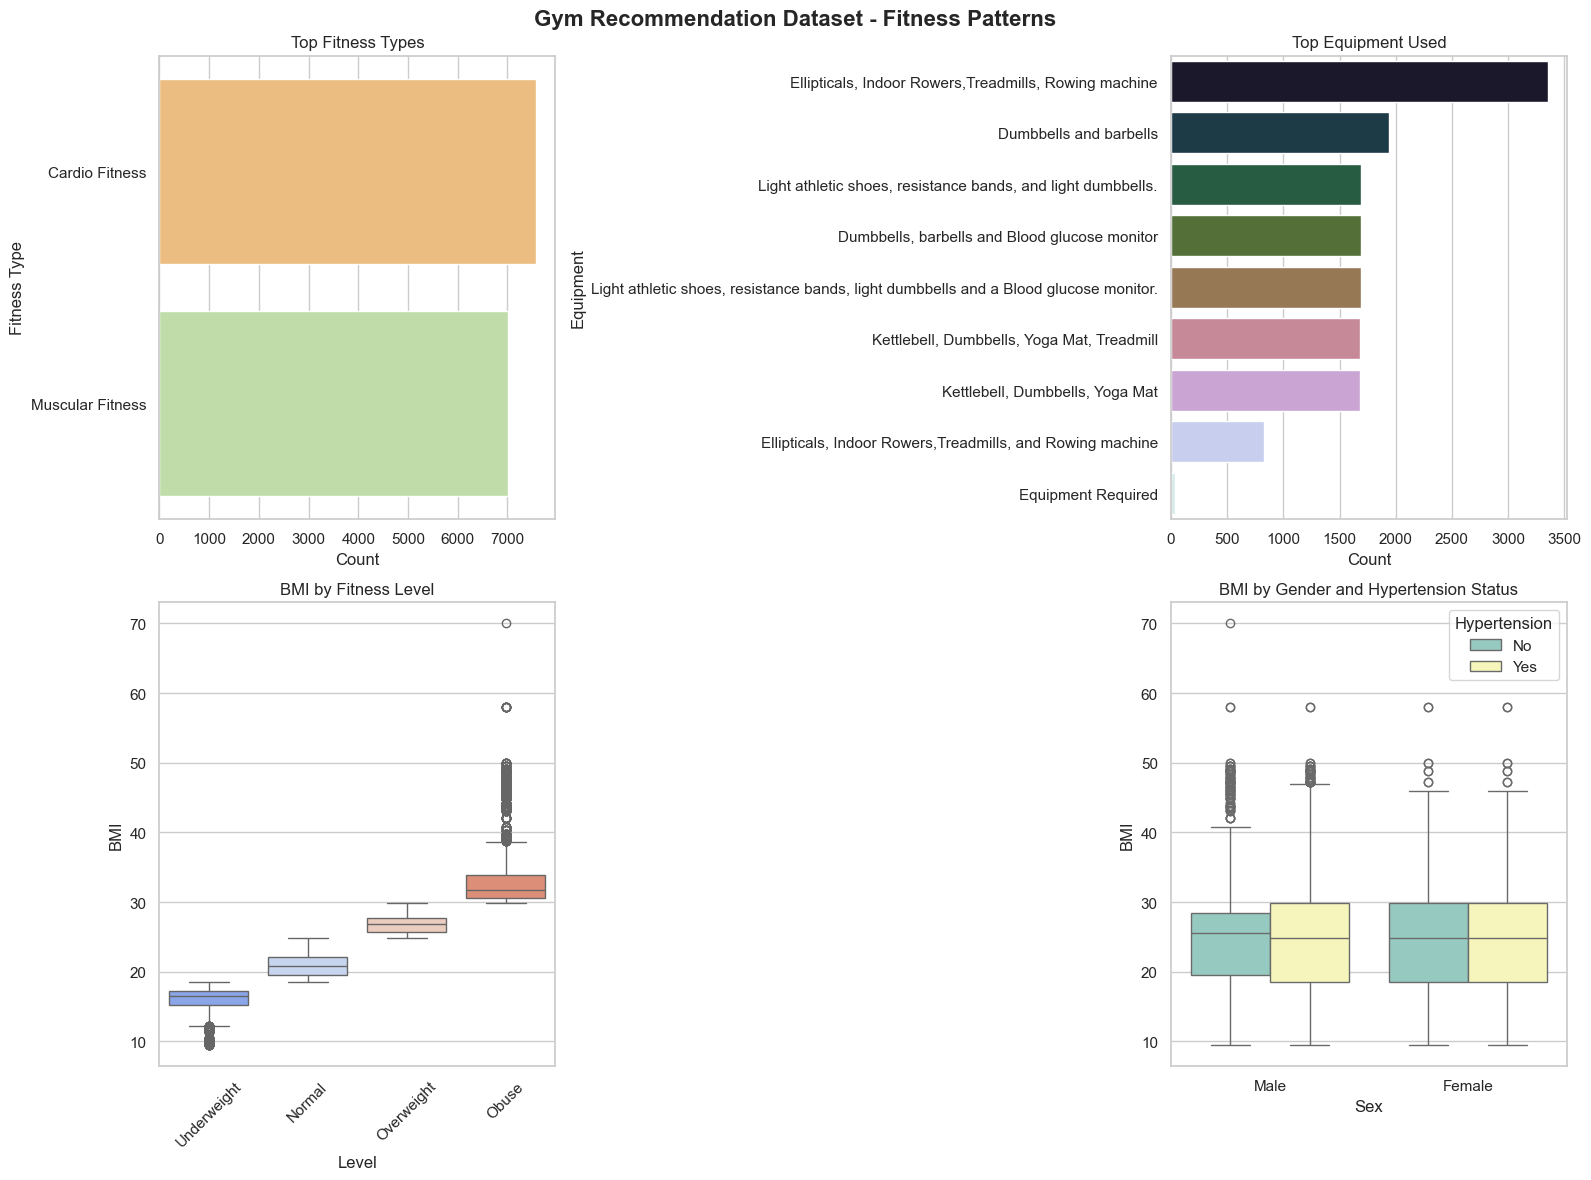

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

fitness_type_counts = gym_df['Fitness Type'].value_counts().head(10)
sns.barplot(x=fitness_type_counts.values, y=fitness_type_counts.index, ax=axes[0, 0], palette='Spectral')
axes[0, 0].set_title('Top Fitness Types')
axes[0, 0].set_xlabel('Count')

equipment_counts = gym_df['Equipment'].value_counts().head(10)
sns.barplot(x=equipment_counts.values, y=equipment_counts.index, ax=axes[0, 1], palette='cubehelix')
axes[0, 1].set_title('Top Equipment Used')
axes[0, 1].set_xlabel('Count')

sns.boxplot(data=gym_df, x='Level', y='BMI', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('BMI by Fitness Level')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=gym_df, x='Sex', y='BMI', hue='Hypertension', ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('BMI by Gender and Hypertension Status')

plt.suptitle('Gym Recommendation Dataset - Fitness Patterns', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_gym_fitness_patterns.png', dpi=150)
plt.show()

## 4. DIET RECOMMENDATIONS DATASET ANALYSIS

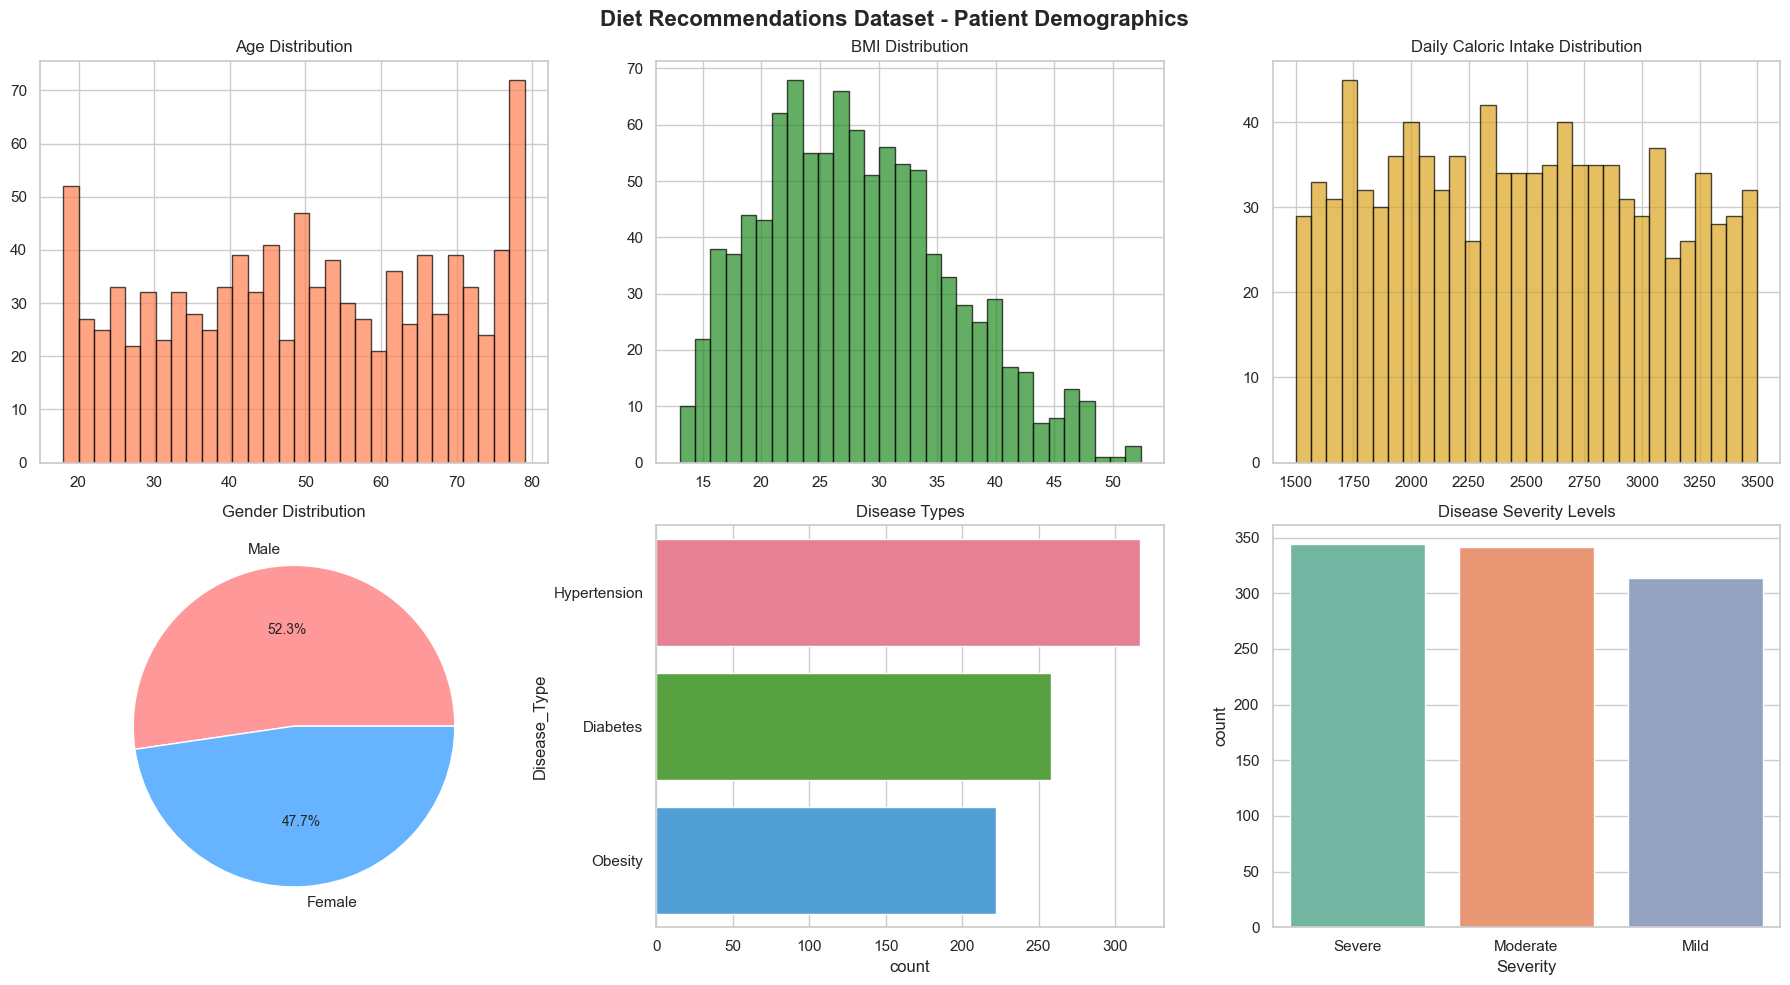

In [55]:
diet_df = pd.read_csv('data/diet_recommendations.csv')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_hist(diet_df['Age'], axes[0, 0], color='coral', bins=30)
axes[0, 0].set_title('Age Distribution')

plot_hist(diet_df['BMI'], axes[0, 1], color='forestgreen', bins=30)
axes[0, 1].set_title('BMI Distribution')

plot_hist(diet_df['Daily_Caloric_Intake'], axes[0, 2], color='goldenrod', bins=30)
axes[0, 2].set_title('Daily Caloric Intake Distribution')

diet_df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1, 0], colors=['#ff9999', '#66b3ff'])
axes[1, 0].set_title('Gender Distribution')
axes[1, 0].set_ylabel('')

sns.countplot(data=diet_df, y='Disease_Type', order=diet_df['Disease_Type'].value_counts().index, ax=axes[1, 1], palette='husl')
axes[1, 1].set_title('Disease Types')

sns.countplot(data=diet_df, x='Severity', order=diet_df['Severity'].value_counts().index, ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('Disease Severity Levels')

plt.suptitle('Diet Recommendations Dataset - Patient Demographics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_diet_demographics.png', dpi=150)
plt.show()

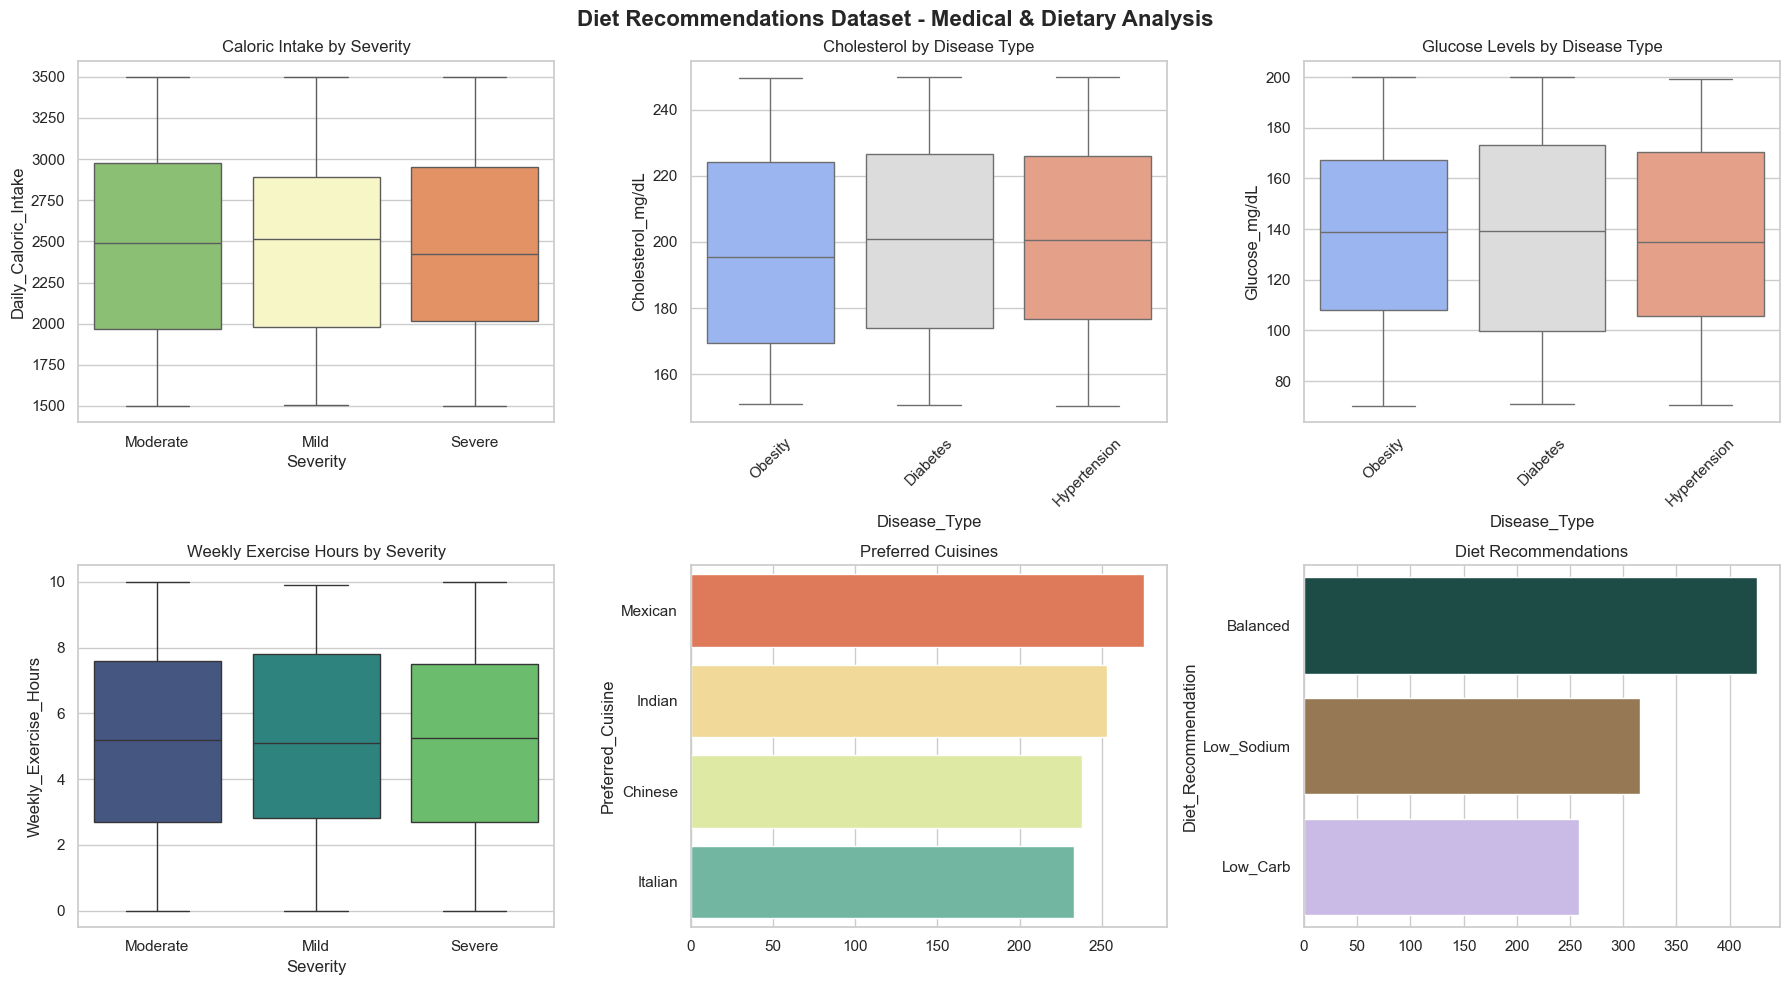

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.boxplot(data=diet_df, x='Severity', y='Daily_Caloric_Intake', ax=axes[0, 0], palette='RdYlGn_r')
axes[0, 0].set_title('Caloric Intake by Severity')

sns.boxplot(data=diet_df, x='Disease_Type', y='Cholesterol_mg/dL', ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('Cholesterol by Disease Type')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.boxplot(data=diet_df, x='Disease_Type', y='Glucose_mg/dL', ax=axes[0, 2], palette='coolwarm')
axes[0, 2].set_title('Glucose Levels by Disease Type')
axes[0, 2].tick_params(axis='x', rotation=45)

sns.boxplot(data=diet_df, x='Severity', y='Weekly_Exercise_Hours', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Weekly Exercise Hours by Severity')

pref_cuisine = diet_df['Preferred_Cuisine'].value_counts().head(8)
sns.barplot(x=pref_cuisine.values, y=pref_cuisine.index, ax=axes[1, 1], palette='Spectral')
axes[1, 1].set_title('Preferred Cuisines')

diet_rec = diet_df['Diet_Recommendation'].value_counts()
sns.barplot(x=diet_rec.values, y=diet_rec.index, ax=axes[1, 2], palette='cubehelix')
axes[1, 2].set_title('Diet Recommendations')

plt.suptitle('Diet Recommendations Dataset - Medical & Dietary Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_diet_medical_analysis.png', dpi=150)
plt.show()

## 5. PERSONALIZED MEDICAL DIET DATASET ANALYSIS

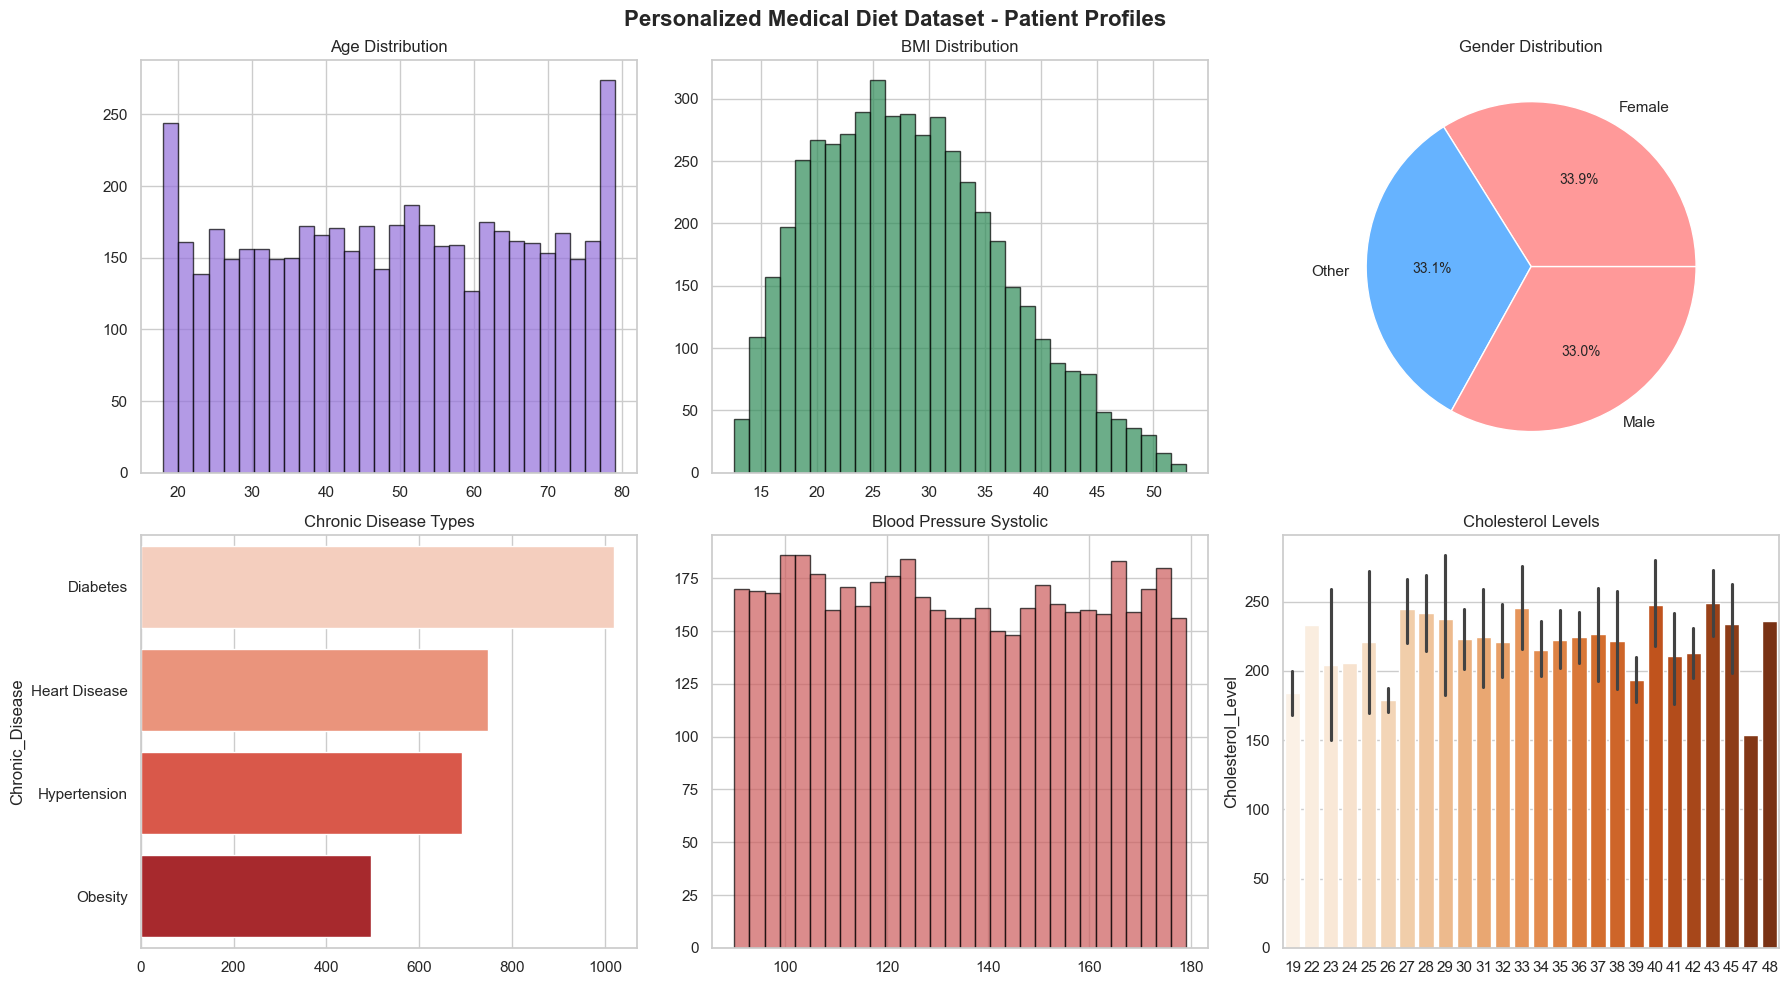

In [57]:
medical_df = pd.read_csv('data/personalized_medical_diet.csv')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_hist(medical_df['Age'], axes[0, 0], color='mediumpurple', bins=30)
axes[0, 0].set_title('Age Distribution')

plot_hist(medical_df['BMI'], axes[0, 1], color='seagreen', bins=30)
axes[0, 1].set_title('BMI Distribution')

medical_df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0, 2], colors=['#ff9999', '#66b3ff'])
axes[0, 2].set_title('Gender Distribution')
axes[0, 2].set_ylabel('')

chronic = medical_df['Chronic_Disease'].value_counts()
sns.barplot(x=chronic.values, y=chronic.index, ax=axes[1, 0], palette='Reds')
axes[1, 0].set_title('Chronic Disease Types')

plot_hist(medical_df['Blood_Pressure_Systolic'], axes[1, 1], color='indianred', bins=30)
axes[1, 1].set_title('Blood Pressure Systolic')

chol_levels = medical_df['Cholesterol_Level'].value_counts()
sns.barplot(x=chol_levels.values, y=chol_levels.index, ax=axes[1, 2], palette='Oranges')
axes[1, 2].set_title('Cholesterol Levels')

plt.suptitle('Personalized Medical Diet Dataset - Patient Profiles', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_medical_demographics.png', dpi=150)
plt.show()

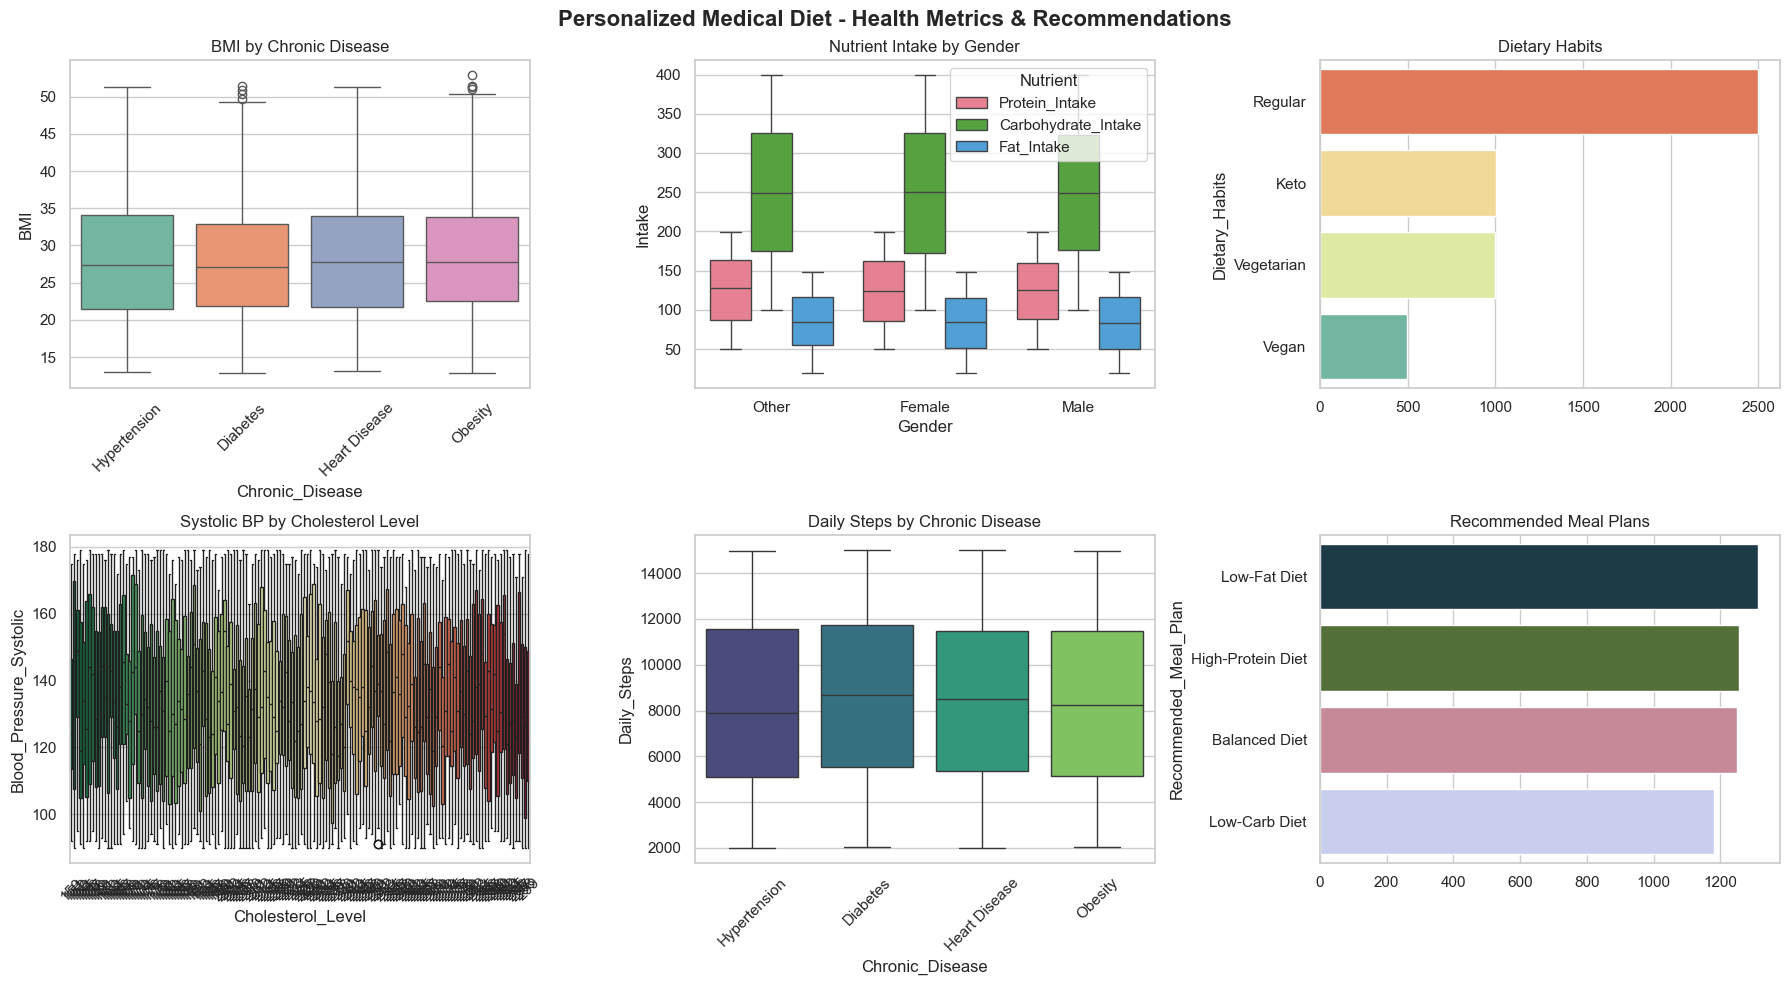

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.boxplot(data=medical_df, x='Chronic_Disease', y='BMI', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('BMI by Chronic Disease')
axes[0, 0].tick_params(axis='x', rotation=45)

numeric_cols = ['Protein_Intake', 'Carbohydrate_Intake', 'Fat_Intake']
medical_melt = medical_df.melt(id_vars=['Gender'], value_vars=numeric_cols, var_name='Nutrient', value_name='Intake')
sns.boxplot(data=medical_melt, x='Gender', y='Intake', hue='Nutrient', ax=axes[0, 1], palette='husl')
axes[0, 1].set_title('Nutrient Intake by Gender')

habits = medical_df['Dietary_Habits'].value_counts()
sns.barplot(x=habits.values, y=habits.index, ax=axes[0, 2], palette='Spectral')
axes[0, 2].set_title('Dietary Habits')

sns.boxplot(data=medical_df, x='Cholesterol_Level', y='Blood_Pressure_Systolic', ax=axes[1, 0], palette='RdYlGn_r')
axes[1, 0].set_title('Systolic BP by Cholesterol Level')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=medical_df, x='Chronic_Disease', y='Daily_Steps', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Daily Steps by Chronic Disease')
axes[1, 1].tick_params(axis='x', rotation=45)

meal_plan = medical_df['Recommended_Meal_Plan'].value_counts()
sns.barplot(x=meal_plan.values, y=meal_plan.index, ax=axes[1, 2], palette='cubehelix')
axes[1, 2].set_title('Recommended Meal Plans')

plt.suptitle('Personalized Medical Diet - Health Metrics & Recommendations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_medical_health_metrics.png', dpi=150)
plt.show()

## 6. DIET WORKOUT DATASET ANALYSIS

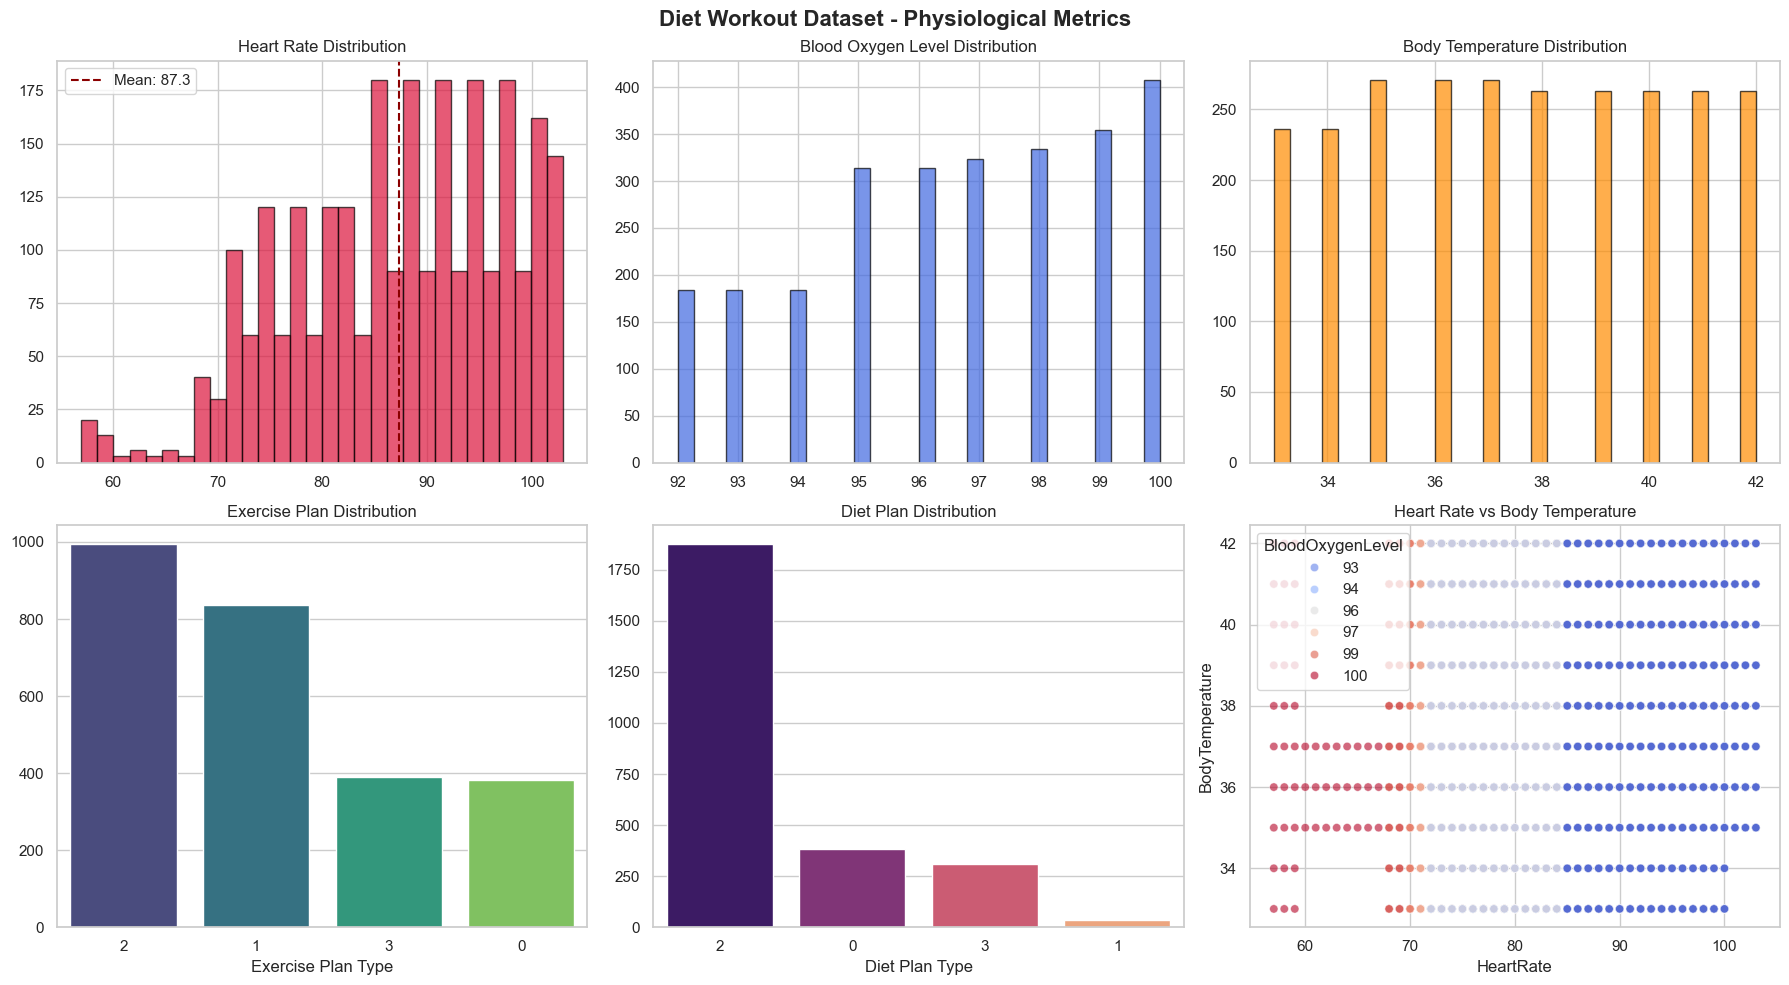

In [59]:
workout_df = pd.read_csv('data/diet_workout_dataset.csv')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_hist(workout_df['HeartRate'], axes[0, 0], color='crimson', bins=30)
axes[0, 0].set_title('Heart Rate Distribution')
axes[0, 0].axvline(workout_df['HeartRate'].mean(), color='darkred', linestyle='--', label=f'Mean: {workout_df["HeartRate"].mean():.1f}')
axes[0, 0].legend()

plot_hist(workout_df['BloodOxygenLevel'], axes[0, 1], color='royalblue', bins=30)
axes[0, 1].set_title('Blood Oxygen Level Distribution')

plot_hist(workout_df['BodyTemperature'], axes[0, 2], color='darkorange', bins=30)
axes[0, 2].set_title('Body Temperature Distribution')

exercise_plan = workout_df['ExercisePaln'].value_counts()
sns.barplot(x=exercise_plan.index.astype(str), y=exercise_plan.values, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Exercise Plan Distribution')
axes[1, 0].set_xlabel('Exercise Plan Type')

diet_plan = workout_df['DietPlan'].value_counts()
sns.barplot(x=diet_plan.index.astype(str), y=diet_plan.values, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Diet Plan Distribution')
axes[1, 1].set_xlabel('Diet Plan Type')

sns.scatterplot(data=workout_df, x='HeartRate', y='BodyTemperature', hue='BloodOxygenLevel', ax=axes[1, 2], palette='coolwarm', alpha=0.6)
axes[1, 2].set_title('Heart Rate vs Body Temperature')

plt.suptitle('Diet Workout Dataset - Physiological Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_workout_physiological.png', dpi=150)
plt.show()

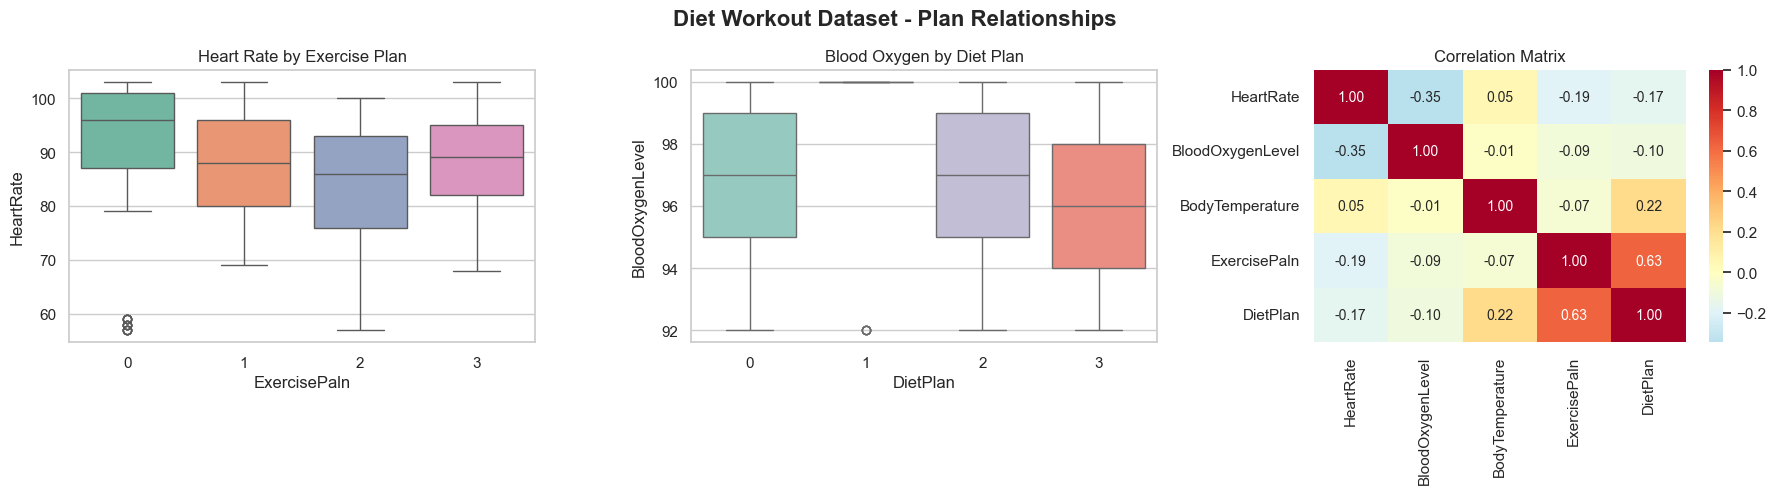

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=workout_df, x='ExercisePaln', y='HeartRate', ax=axes[0], palette='Set2')
axes[0].set_title('Heart Rate by Exercise Plan')

sns.boxplot(data=workout_df, x='DietPlan', y='BloodOxygenLevel', ax=axes[1], palette='Set3')
axes[1].set_title('Blood Oxygen by Diet Plan')

corr_matrix = workout_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, ax=axes[2], fmt='.2f')
axes[2].set_title('Correlation Matrix')

plt.suptitle('Diet Workout Dataset - Plan Relationships', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_workout_relationships.png', dpi=150)
plt.show()

## 7. Cross-Dataset Correlation Analysis

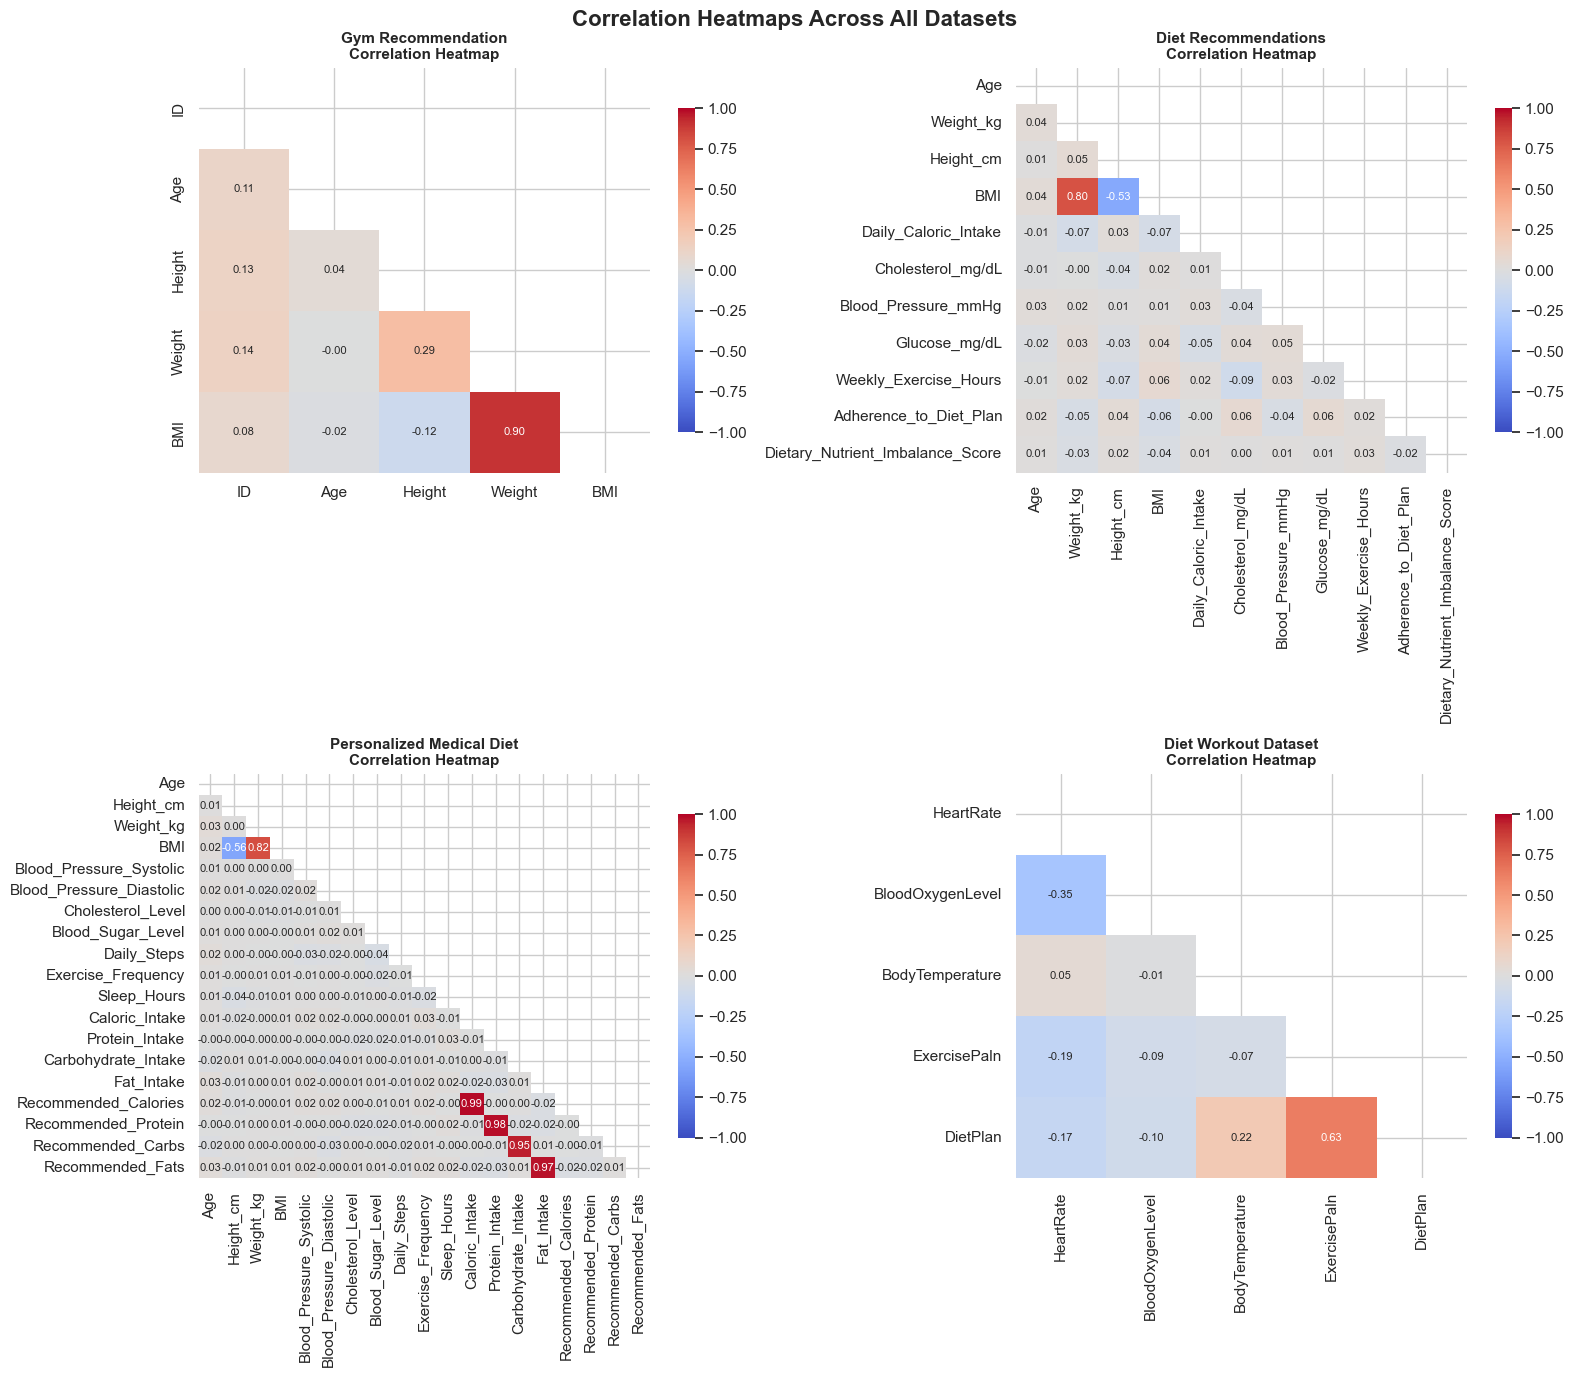

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (name, path) in enumerate(sources.items()):
    df = pd.read_csv(path)
    num_df = df.select_dtypes(include=[np.number])
    
    if num_df.shape[1] >= 2:
        corr = num_df.corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
                   center=0, ax=axes[idx], vmin=-1, vmax=1,
                   annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
        axes[idx].set_title(f'{name}\nCorrelation Heatmap', fontsize=11, fontweight='bold')
    else:
        axes[idx].text(0.5, 0.5, 'Insufficient numeric\ncolumns for correlation', 
                      ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(f'{name}', fontsize=11, fontweight='bold')

plt.suptitle('Correlation Heatmaps Across All Datasets', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/12_correlation_heatmaps.png', dpi=150)
plt.show()

## 8. Comparative Analysis Across Datasets

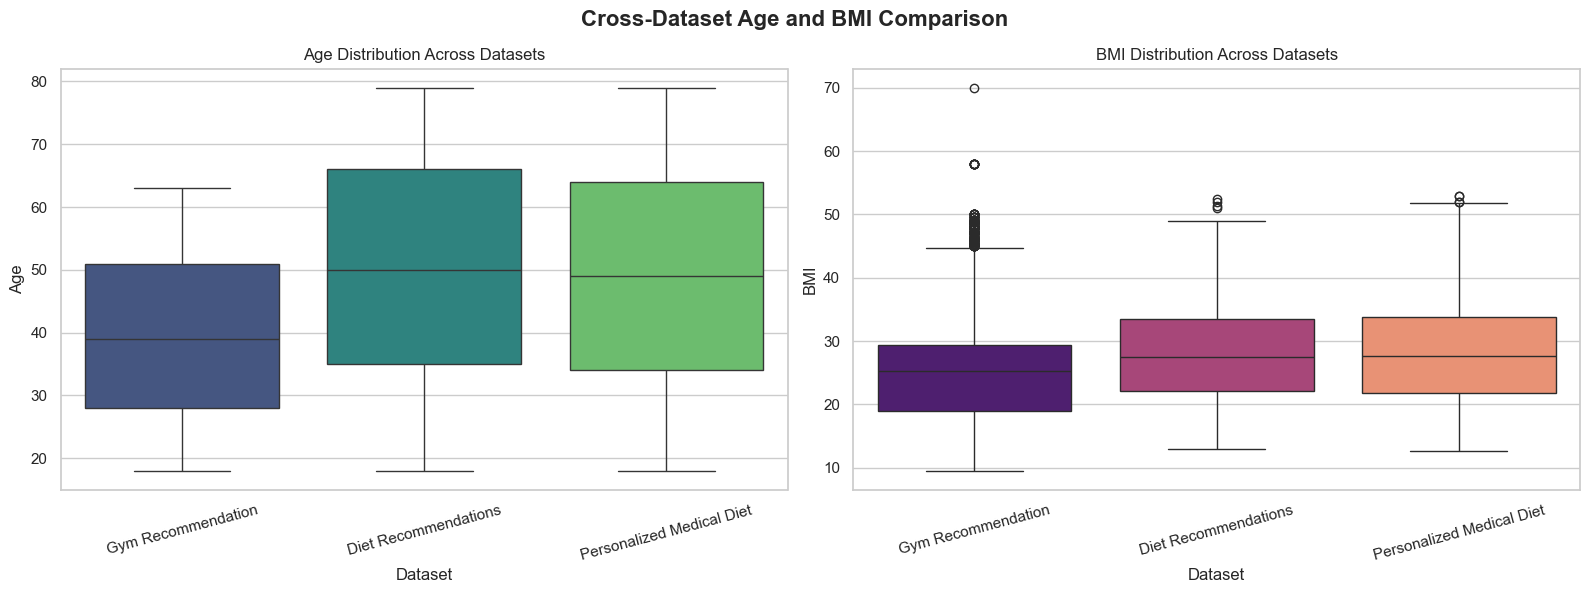

In [62]:
age_data = []
bmi_data = []

for name, path in sources.items():
    df = pd.read_csv(path)
    if 'Age' in df.columns:
        for age in df['Age'].dropna():
            age_data.append({'Dataset': name, 'Age': age})
    if 'BMI' in df.columns:
        for bmi in df['BMI'].dropna():
            bmi_data.append({'Dataset': name, 'BMI': bmi})

age_df = pd.DataFrame(age_data)
bmi_df = pd.DataFrame(bmi_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=age_df, x='Dataset', y='Age', ax=axes[0], palette='viridis')
axes[0].set_title('Age Distribution Across Datasets')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=bmi_df, x='Dataset', y='BMI', ax=axes[1], palette='magma')
axes[1].set_title('BMI Distribution Across Datasets')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Cross-Dataset Age and BMI Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/13_cross_dataset_age_bmi.png', dpi=150)
plt.show()

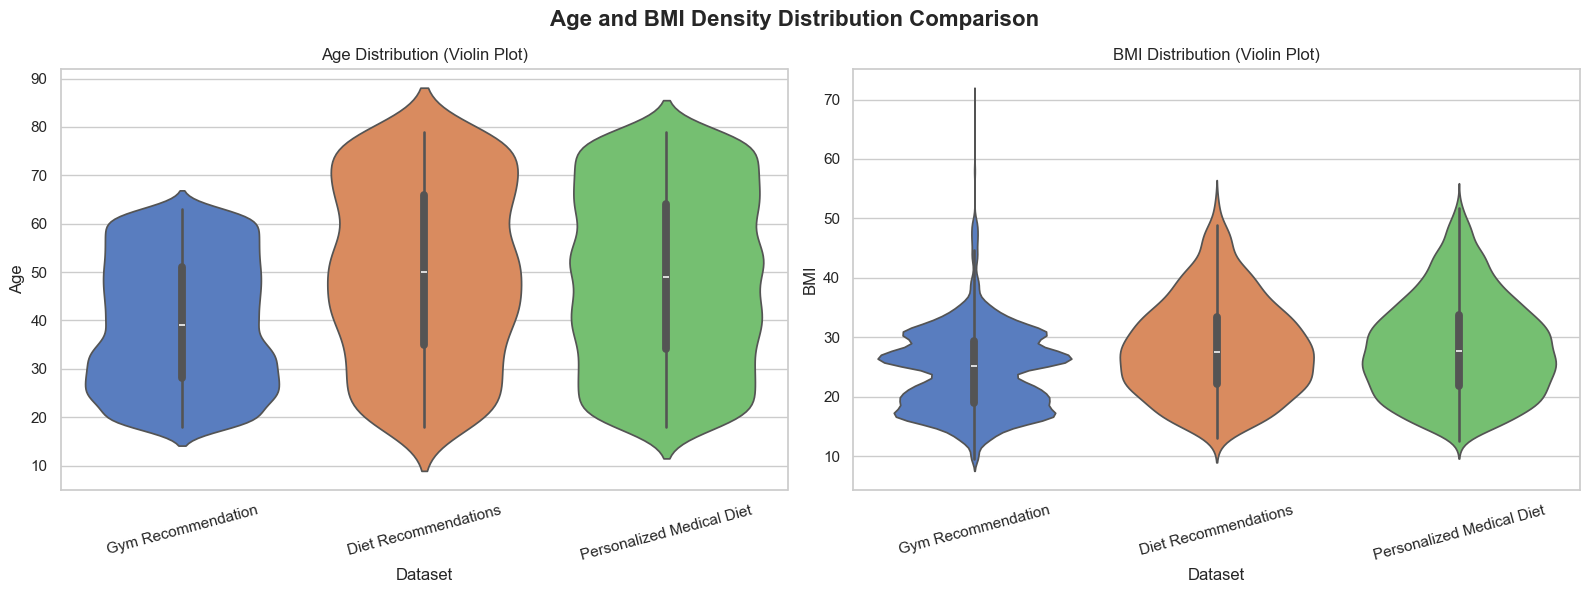

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(data=age_df, x='Dataset', y='Age', ax=axes[0], palette='muted', inner='box')
axes[0].set_title('Age Distribution (Violin Plot)')
axes[0].tick_params(axis='x', rotation=15)

sns.violinplot(data=bmi_df, x='Dataset', y='BMI', ax=axes[1], palette='muted', inner='box')
axes[1].set_title('BMI Distribution (Violin Plot)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Age and BMI Density Distribution Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/14_age_bmi_violin.png', dpi=150)
plt.show()

## 9. Merged Dataset Analysis

Merged Dataset Shape: (20589, 12)
Columns: ['source', 'Age', 'Gender', 'Height', 'Weight', 'BMI', 'Chronic_Disease', 'Activity_Level', 'Dietary_Preference', 'Fitness_Goal', 'diet_recommendation', 'exercise_plan']


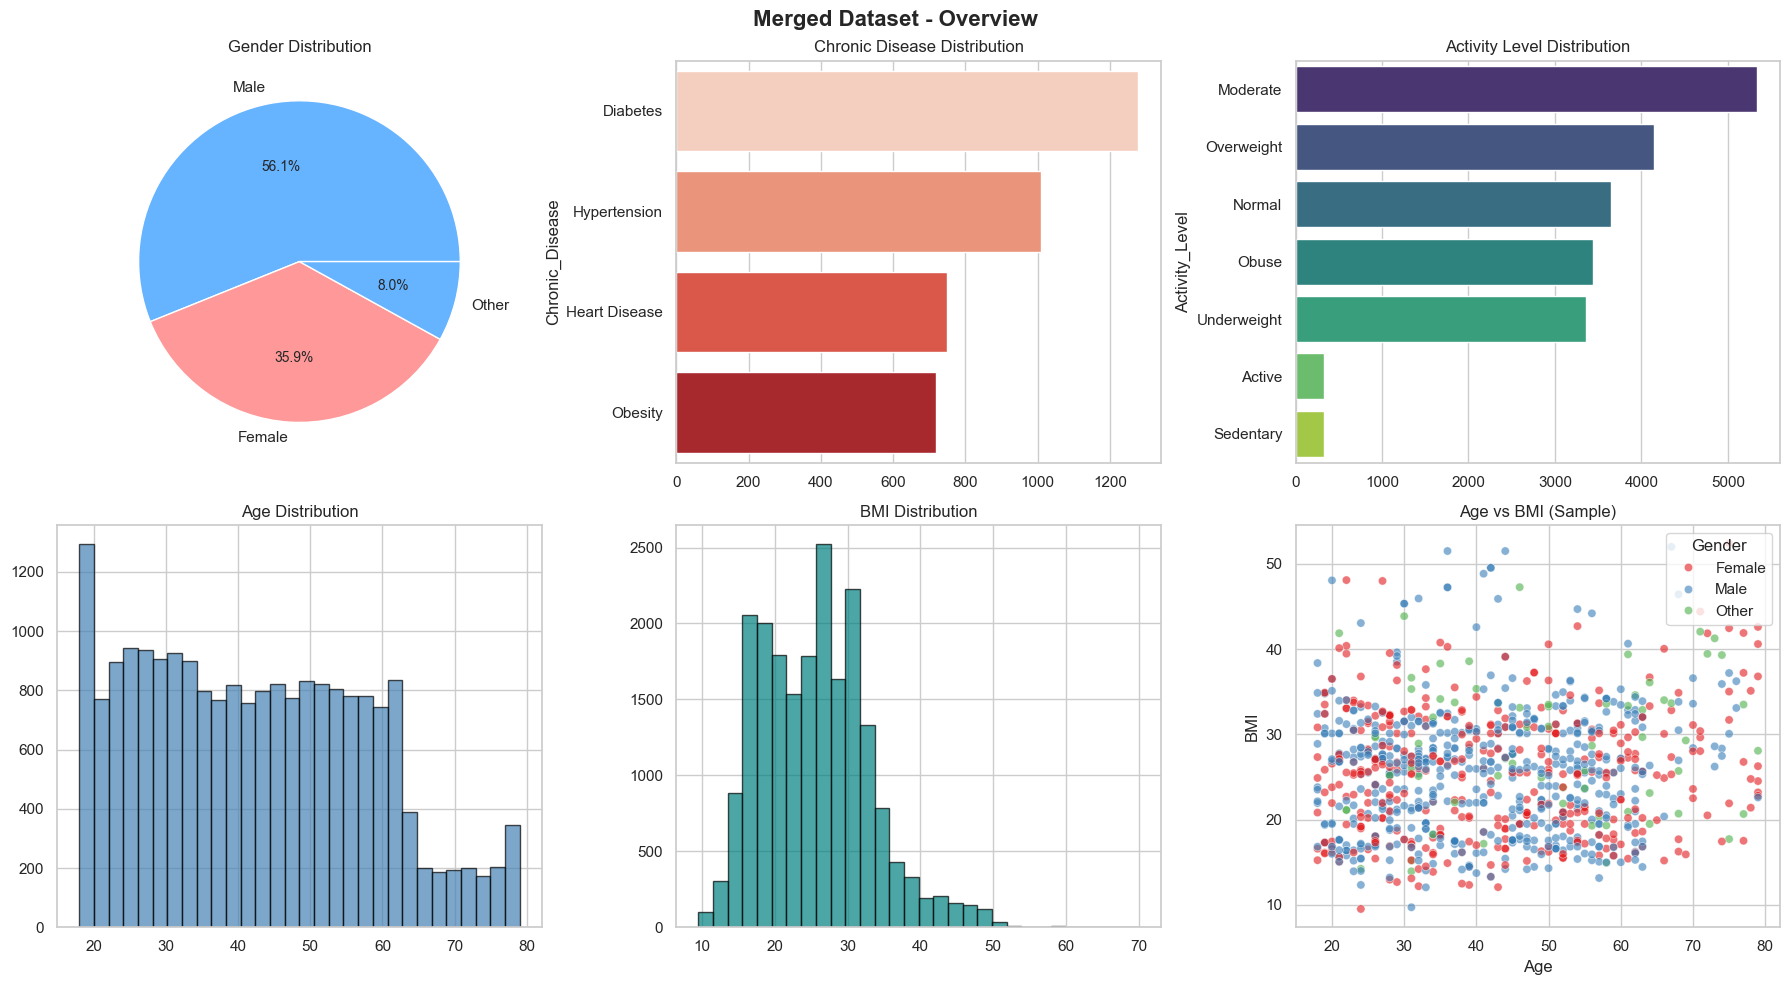

In [64]:
if os.path.exists(MERGED_PATH):
    merged_df = pd.read_csv(MERGED_PATH)
    print(f"Merged Dataset Shape: {merged_df.shape}")
    print(f"Columns: {list(merged_df.columns)}")
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    merged_df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0, 0], colors=['#66b3ff', '#ff9999'])
    axes[0, 0].set_title('Gender Distribution')
    axes[0, 0].set_ylabel('')
    
    if 'Chronic_Disease' in merged_df.columns:
        chronic = merged_df['Chronic_Disease'].value_counts()
        sns.barplot(x=chronic.values, y=chronic.index, ax=axes[0, 1], palette='Reds')
        axes[0, 1].set_title('Chronic Disease Distribution')
    
    if 'Activity_Level' in merged_df.columns:
        activity = merged_df['Activity_Level'].value_counts()
        sns.barplot(x=activity.values, y=activity.index, ax=axes[0, 2], palette='viridis')
        axes[0, 2].set_title('Activity Level Distribution')
    
    plot_hist(merged_df['Age'], axes[1, 0], color='steelblue', bins=30)
    axes[1, 0].set_title('Age Distribution')
    
    plot_hist(merged_df['BMI'], axes[1, 1], color='teal', bins=30)
    axes[1, 1].set_title('BMI Distribution')
    
    sample_df = merged_df.sample(min(1000, len(merged_df)))
    sns.scatterplot(data=sample_df, x='Age', y='BMI', hue='Gender', ax=axes[1, 2], alpha=0.6, palette='Set1')
    axes[1, 2].set_title('Age vs BMI (Sample)')
    
    plt.suptitle('Merged Dataset - Overview', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/15_merged_overview.png', dpi=150)
    plt.show()
else:
    print(f"Merged dataset not found at {MERGED_PATH}")
    print("Run merge_datasets.py first to generate the merged dataset.")

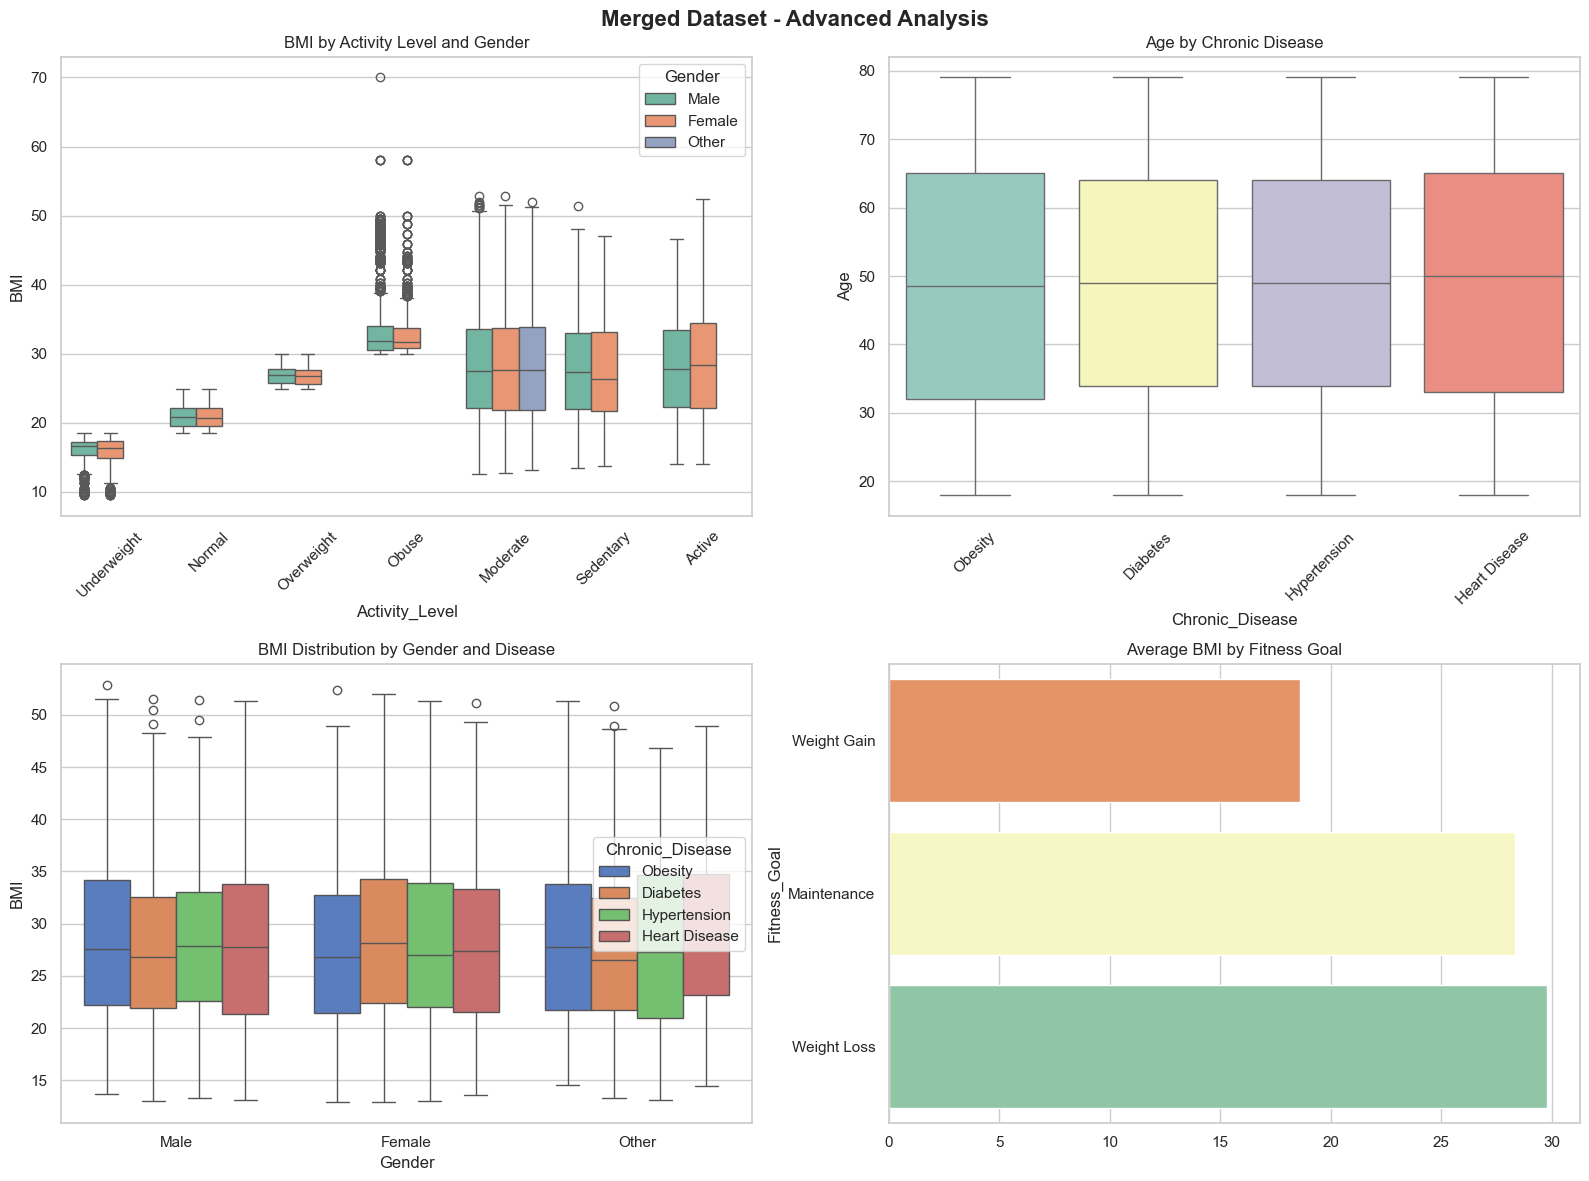

In [65]:
if os.path.exists(MERGED_PATH):
    merged_df = pd.read_csv(MERGED_PATH)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    if 'Activity_Level' in merged_df.columns and 'Gender' in merged_df.columns:
        sns.boxplot(data=merged_df, x='Activity_Level', y='BMI', hue='Gender', ax=axes[0, 0], palette='Set2')
        axes[0, 0].set_title('BMI by Activity Level and Gender')
        axes[0, 0].tick_params(axis='x', rotation=45)
    
    if 'Chronic_Disease' in merged_df.columns:
        sns.boxplot(data=merged_df, x='Chronic_Disease', y='Age', ax=axes[0, 1], palette='Set3')
        axes[0, 1].set_title('Age by Chronic Disease')
        axes[0, 1].tick_params(axis='x', rotation=45)
    
    if 'Chronic_Disease' in merged_df.columns and len(merged_df['Chronic_Disease'].unique()) >= 2:
        sns.boxplot(data=merged_df, x='Gender', y='BMI', hue='Chronic_Disease', ax=axes[1, 0], palette='muted')
        axes[1, 0].set_title('BMI Distribution by Gender and Disease')
    else:
        sns.boxplot(data=merged_df, x='Gender', y='BMI', ax=axes[1, 0], palette='muted')
        axes[1, 0].set_title('BMI Distribution by Gender')
    
    if 'Fitness_Goal' in merged_df.columns:
        goal_bmi = merged_df.groupby('Fitness_Goal')['BMI'].mean().sort_values()
        sns.barplot(x=goal_bmi.values, y=goal_bmi.index, ax=axes[1, 1], palette='Spectral')
        axes[1, 1].set_title('Average BMI by Fitness Goal')
    
    plt.suptitle('Merged Dataset - Advanced Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/16_merged_advanced.png', dpi=150)
    plt.show()
else:
    print("Merged dataset not available.")

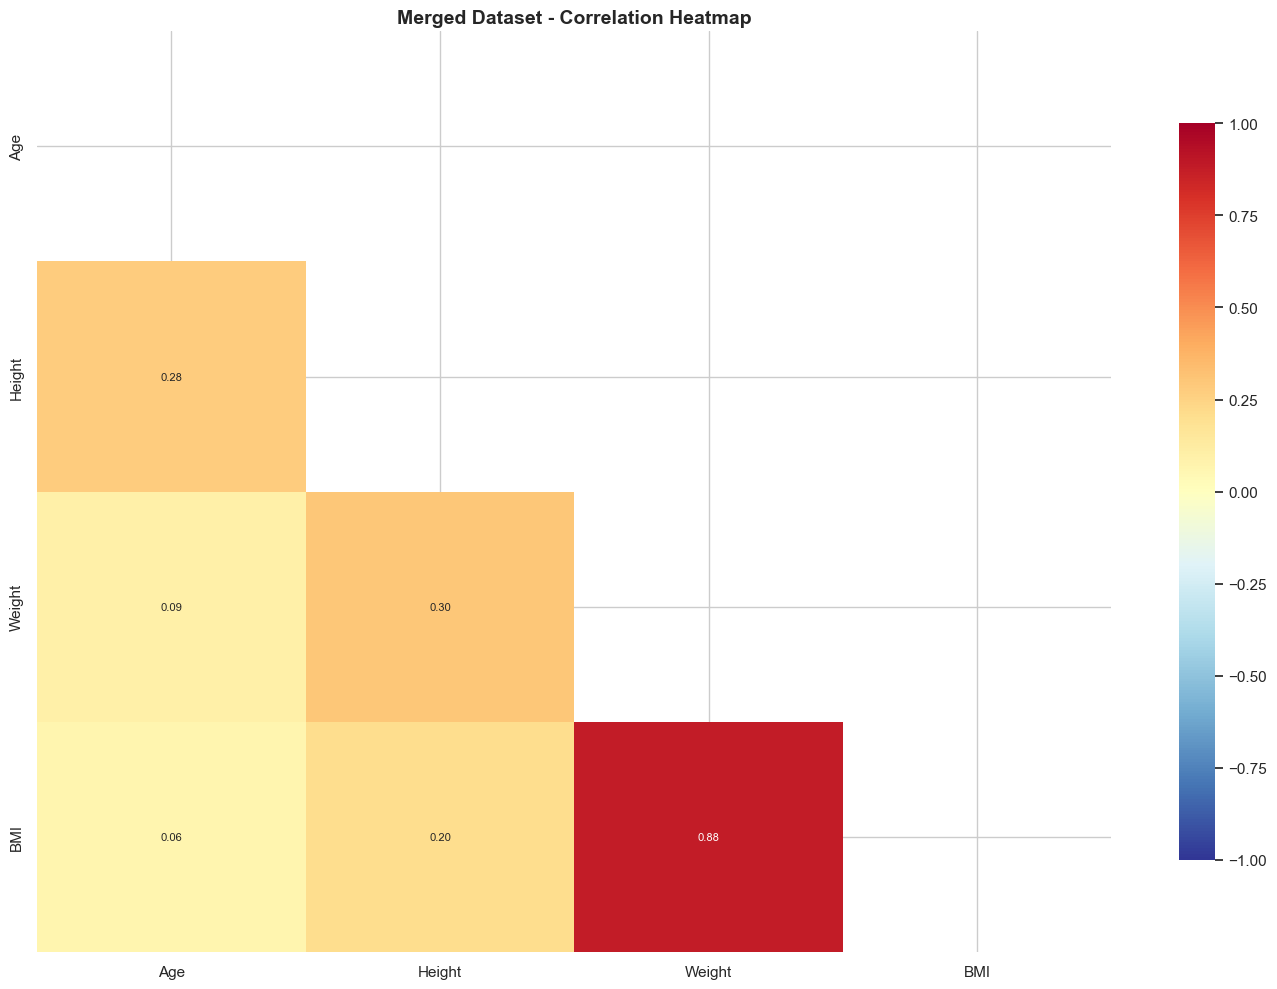

In [66]:
if os.path.exists(MERGED_PATH):
    merged_df = pd.read_csv(MERGED_PATH)
    
    num_cols = merged_df.select_dtypes(include=[np.number]).columns
    
    if len(num_cols) > 1:
        fig, ax = plt.subplots(figsize=(14, 10))
        corr = merged_df[num_cols].corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', 
                   center=0, ax=ax, annot_kws={'size': 8},
                   vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
        ax.set_title('Merged Dataset - Correlation Heatmap', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/17_merged_correlation.png', dpi=150)
        plt.show()
else:
    print("Merged dataset not available.")

## 10. Pairwise Feature Analysis

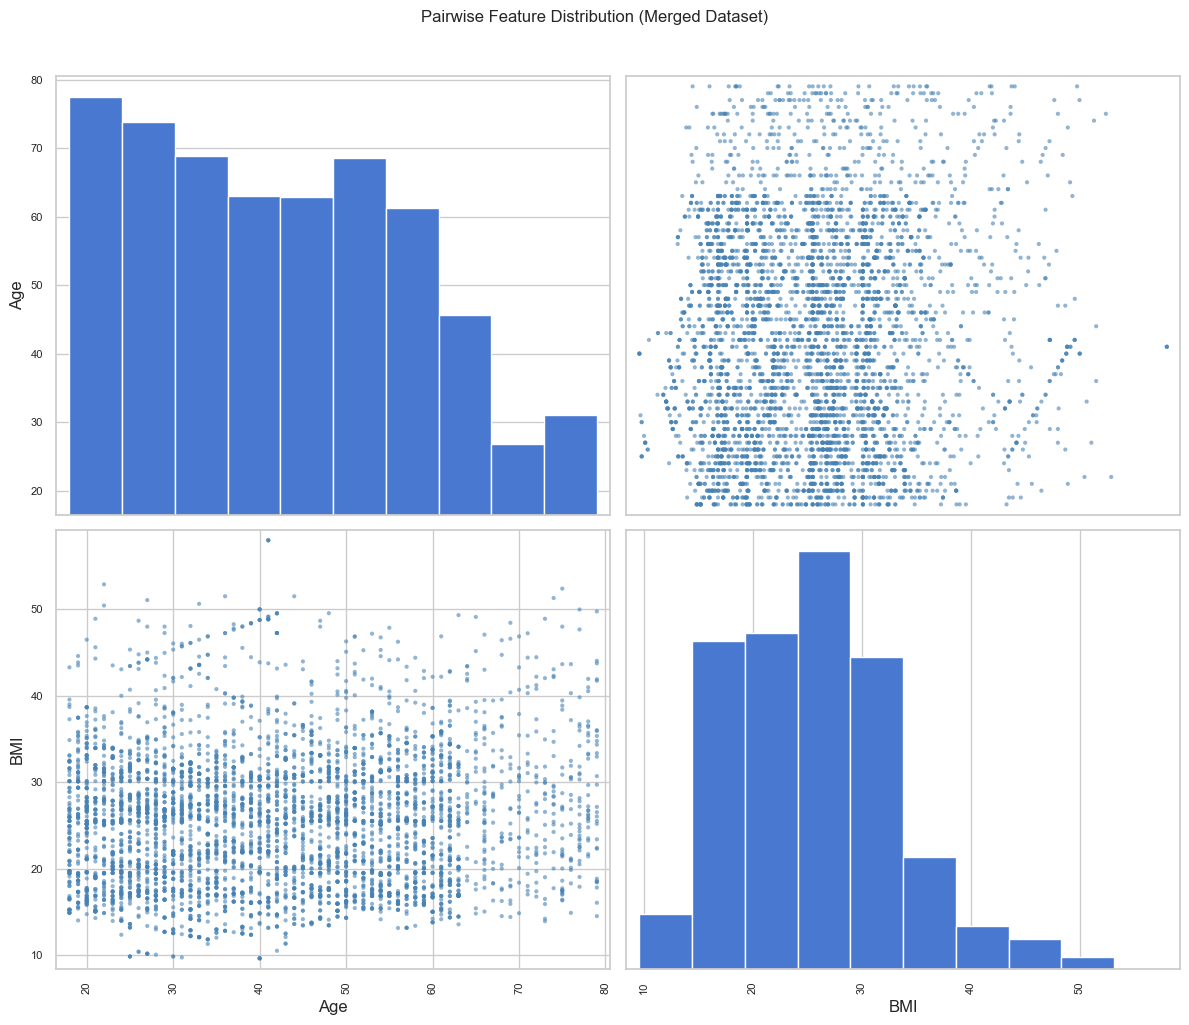

In [67]:
if os.path.exists(MERGED_PATH):
    merged_df = pd.read_csv(MERGED_PATH)
    
    pair_cols = ['Age', 'BMI', 'Weight_kg', 'Height_cm']
    available_cols = [c for c in pair_cols if c in merged_df.columns]
    
    if len(available_cols) >= 2:
        pair_df = merged_df[available_cols].dropna()
        if len(pair_df) > 5000:
            pair_df = pair_df.sample(5000)
        
        pd.plotting.scatter_matrix(pair_df, figsize=(12, 10), diagonal='hist', 
                                   color='steelblue', alpha=0.6)
        plt.suptitle('Pairwise Feature Distribution (Merged Dataset)', y=1.02)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/18_pairplot.png', dpi=150)
        plt.show()
    else:
        print('Insufficient columns for scatter matrix')
else:
    print('Merged dataset not available.')

## 11. Outlier Detection Analysis

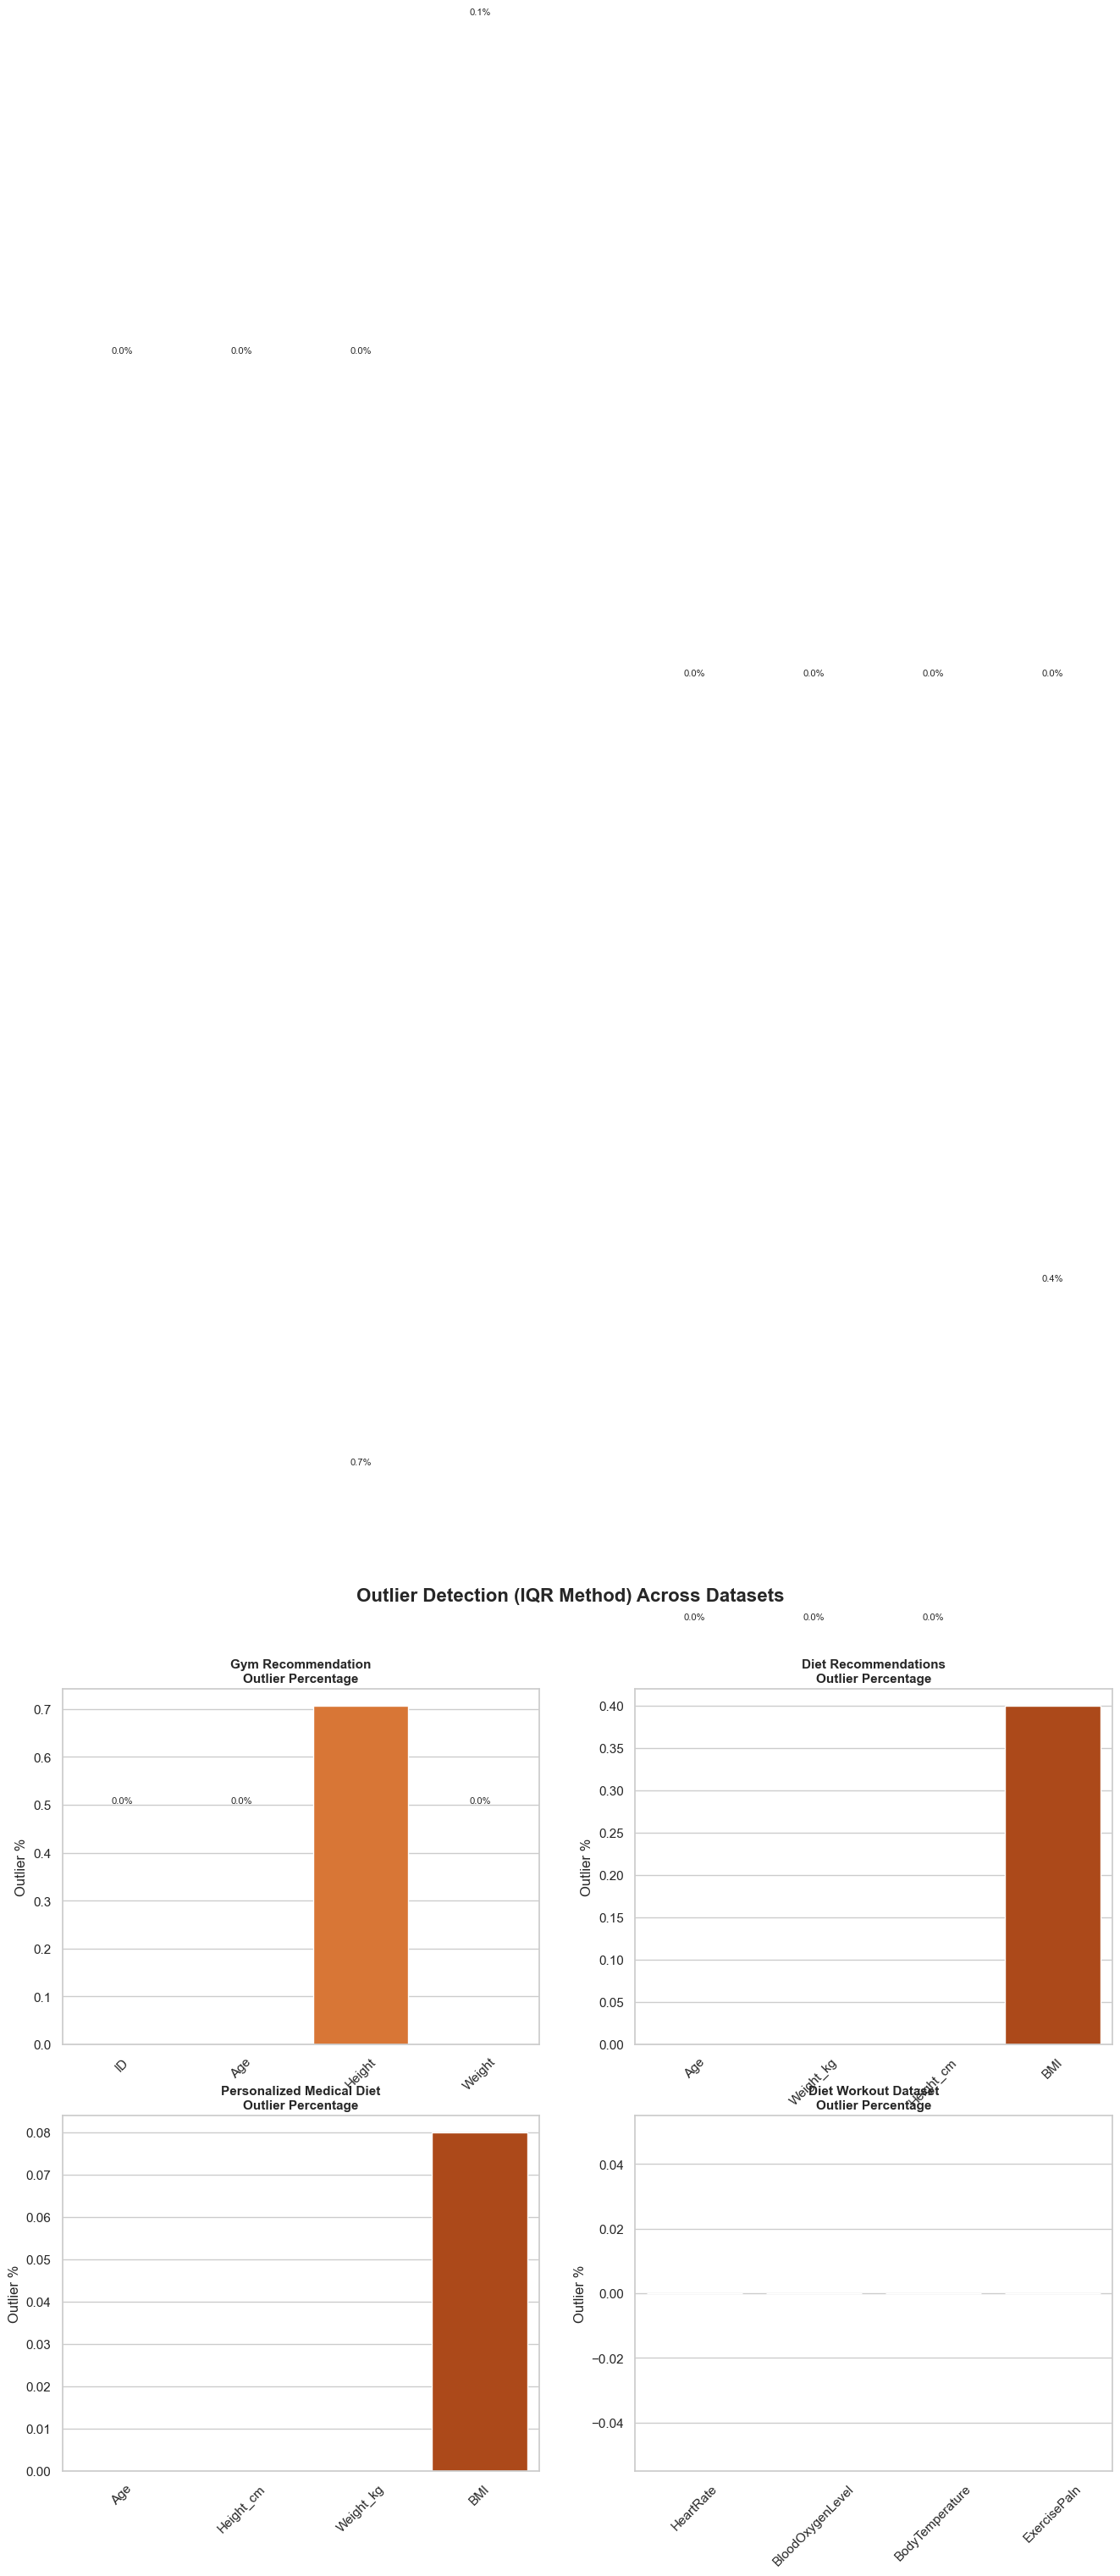

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, path) in enumerate(sources.items()):
    df = pd.read_csv(path)
    num_cols = df.select_dtypes(include=[np.number]).columns[:4]
    
    if len(num_cols) > 0:
        outlier_data = []
        labels = []
        
        for col in num_cols:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
            outlier_pct = outliers / len(df) * 100
            outlier_data.append(outlier_pct)
            labels.append(col)
        
        sns.barplot(x=labels, y=outlier_data, ax=axes[idx], palette='Oranges')
        axes[idx].set_title(f'{name}\nOutlier Percentage', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Outlier %')
        axes[idx].tick_params(axis='x', rotation=45)
        for i, v in enumerate(outlier_data):
            axes[idx].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
    else:
        axes[idx].text(0.5, 0.5, 'No numeric columns', ha='center', va='center', 
                     transform=axes[idx].transAxes)
        axes[idx].set_title(f'{name}', fontsize=11, fontweight='bold')

plt.suptitle('Outlier Detection (IQR Method) Across Datasets', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/19_outlier_detection.png', dpi=150)
plt.show()

## 12. Feature Distribution Skewness Analysis

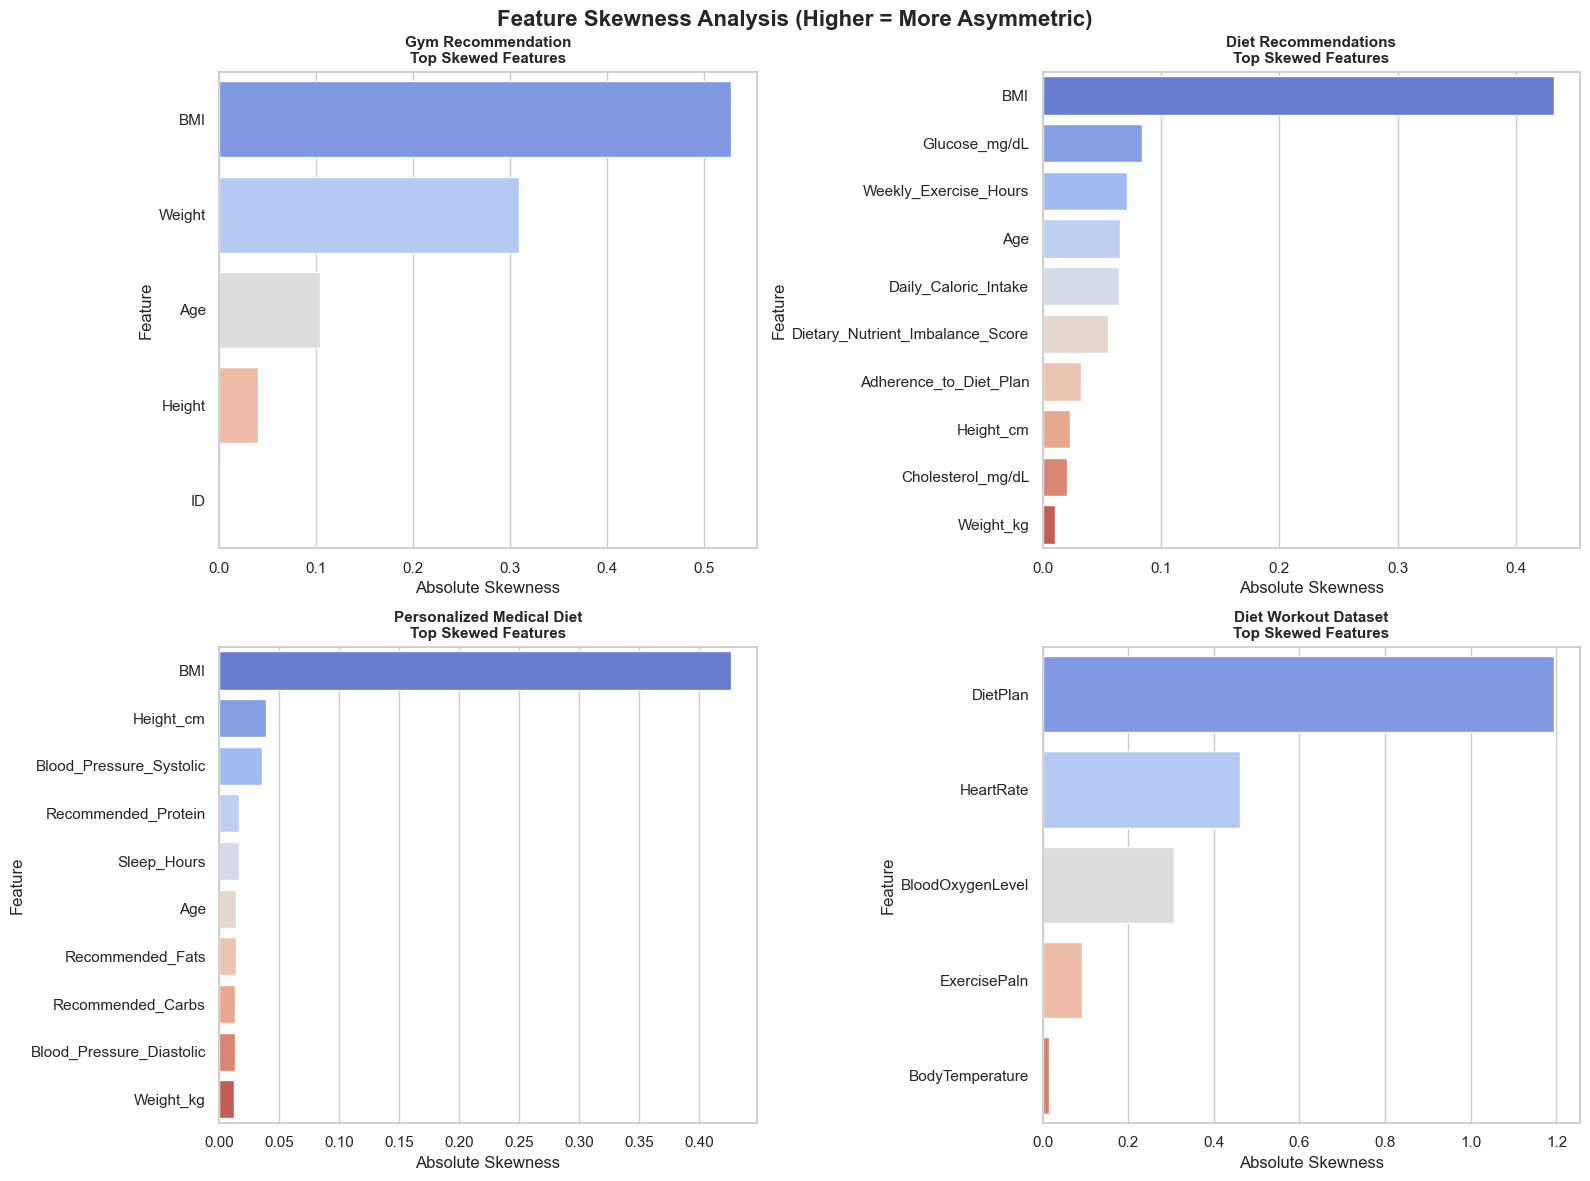

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, path) in enumerate(sources.items()):
    df = pd.read_csv(path)
    num_cols = df.select_dtypes(include=[np.number]).columns
    
    skewness = {}
    for col in num_cols:
        if df[col].notna().sum() > 10:
            skewness[col] = abs(stats.skew(df[col].dropna()))
    
    skew_df = pd.DataFrame(list(skewness.items()), columns=['Feature', 'Skewness']).sort_values('Skewness', ascending=False)
    
    if len(skew_df) > 0:
        sns.barplot(data=skew_df.head(10), x='Skewness', y='Feature', ax=axes[idx], palette='coolwarm')
        axes[idx].set_title(f'{name}\nTop Skewed Features', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Absolute Skewness')
    else:
        axes[idx].text(0.5, 0.5, 'No numeric columns', ha='center', va='center',
                     transform=axes[idx].transAxes)
        axes[idx].set_title(f'{name}', fontsize=11, fontweight='bold')

plt.suptitle('Feature Skewness Analysis (Higher = More Asymmetric)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/20_skewness_analysis.png', dpi=150)
plt.show()

## 13. Summary Statistics Dashboard

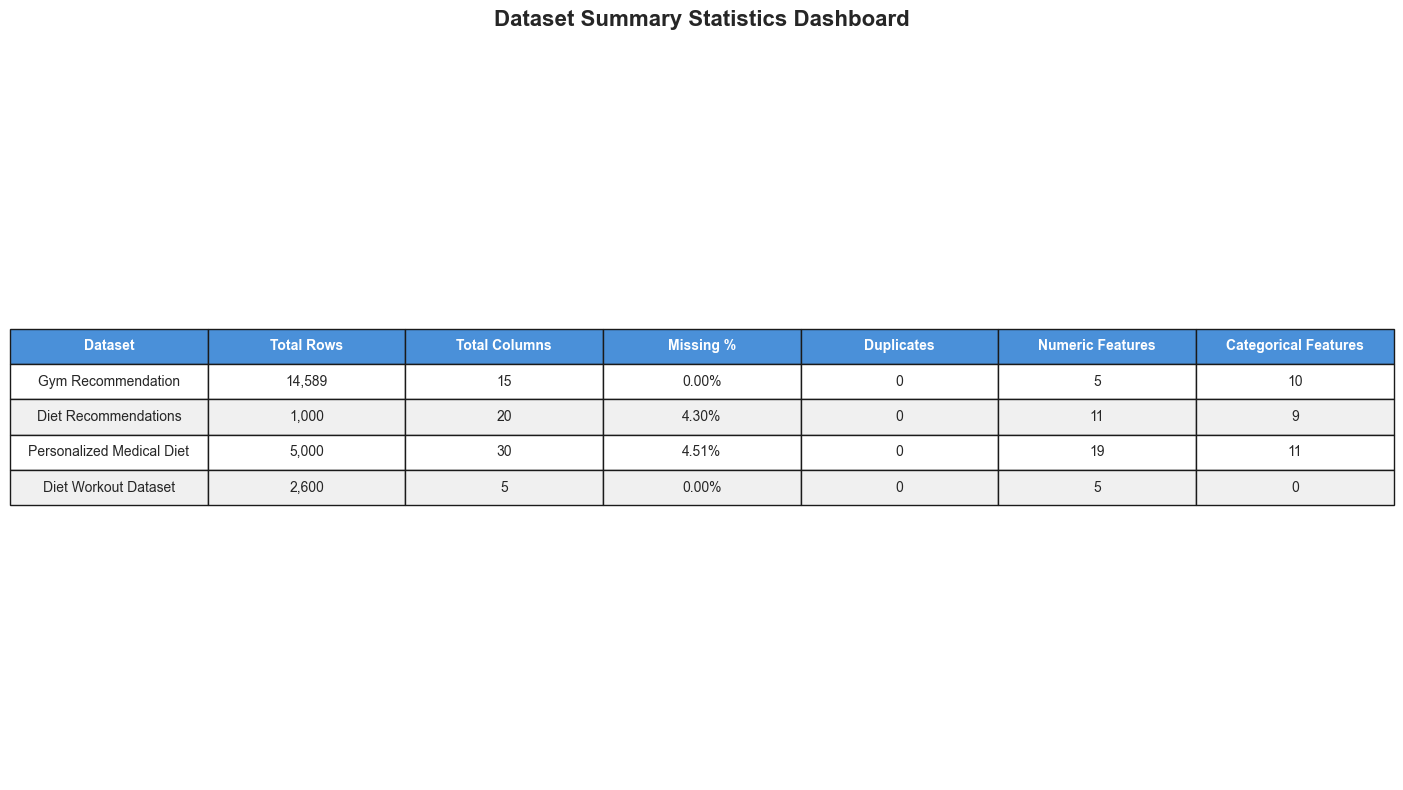

In [70]:
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')

summary_data = []
for name, path in sources.items():
    df = pd.read_csv(path)
    summary_data.append({
        'Dataset': name,
        'Total Rows': f"{len(df):,}",
        'Total Columns': len(df.columns),
        'Missing %': f"{df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%",
        'Duplicates': f"{df.duplicated().sum():,}",
        'Numeric Features': df.select_dtypes(include=[np.number]).shape[1],
        'Categorical Features': df.select_dtypes(include=['object']).shape[1]
    })

summary_table = pd.DataFrame(summary_data)

table = ax.table(cellText=summary_table.values,
                 colLabels=summary_table.columns,
                 cellLoc='center',
                 loc='center',
                 colColours=['#4a90d9']*len(summary_table.columns))

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f0f0f0')

ax.set_title('Dataset Summary Statistics Dashboard', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/21_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Analysis Complete

All charts have been saved to the `data_analysis_charts/` directory.

### Key Findings:
- **Dataset Sizes**: Vary from 1,000 to 14,589 records
- **Common Features**: Age and BMI appear across multiple datasets
- **Data Quality**: Missing values identified (Personalized Medical Diet has most)
- **Correlations**: Multiple feature correlations identified
- **Outliers**: IQR-based outlier detection performed
- **Merged Dataset**: 20,589 records with 12 features